# Convergent Probe CBED — Au [110]

Thickness-resolved high-angle CBED comparison for Au [110].

- **Ground truth**: Second-Order Wave ODE sampled at every unit-cell exit plane
- **Test methods**: Fresnel multislice, Angular Spectrum multislice, and WPM
- **Probe angles**: 25, 50, 100, and 200 mrad
- **Thickness**: repeated Au [110] unit cells up to approximately 100 nm
- **Z-sampling**: 64 slices/cell for the ODE reference, 32 slices/cell for test methods
- **Stored outputs**: per-unit-cell errors, per-unit-cell timings, and final CBED patterns for later plotting


In [49]:
%matplotlib inline

import os
from pathlib import Path
from time import perf_counter

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".7"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk, surface
from matplotlib.colors import LogNorm, TwoSlopeNorm

from wide_angle_propagation.propagation_methods import (
    angular_spectrum_propagation_kernel,
    energy2wavelength,
    fresnel_propagation_kernel,
    simulate_fresnel_as,
    simulate_kg_ode_full,
    simulate_wpm,
)

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)


## Experiment setup

The simulation uses one Au [110] unit cell potential and repeats it until the cumulative thickness reaches approximately 100 nm. Results are recorded after each unit cell.

In [50]:
# --- Experiment parameters ---
energy = 200e3
a_Au = 4.076
TARGET_THICKNESS_NM = 100.0
PROBE_ANGLES_MRAD = np.array([25.0, 50.0, 100.0, 200.0], dtype=float)

# Recommended for 200 mrad with a ~10-12 Å field of view.
ODE_GPTS = (256, 256)
ODE_SLICES_PER_CELL = 64
TEST_SLICES_PER_CELL = 32

RUN_WPM = True
SAVE_RESULTS_NPZ = True
LOAD_EXISTING_RESULTS = True
RECOMPUTE_SIMULATION = False
RESULTS_FILENAME = "cbed_thickness_series_au110_100nm.npz"

# Central-ring analysis mask, scaled to each probe semi-angle.
CENTRAL_RING_INNER_FRACTION = 0.65
CENTRAL_RING_OUTER_FRACTION = 1.05
CENTRAL_ZOOM_OUTER_FRACTION = 1.25
# Single cutoff used for all CBED image panels (same angular window everywhere).
CENTRAL_VIEW_CUTOFF_MRAD = 100.0

# --- Build Au [110] orthogonal unit cell ---
au_bulk = bulk("Au", "fcc", a=a_Au)
au_110 = surface(au_bulk, (1, 1, 0), layers=2)
unit_cell = abtem.orthogonalize_cell(au_110)

z_period = a_Au / np.sqrt(2)
unit_cell.cell[2, 2] = z_period
unit_cell.pbc = [True, True, True]

nx_rep = int(np.ceil(10 / unit_cell.cell.lengths()[0]))
ny_rep = int(np.ceil(10 / unit_cell.cell.lengths()[1]))
n_unit_cells = int(np.ceil((10.0 * TARGET_THICKNESS_NM) / z_period))
actual_thickness_nm = n_unit_cells * z_period / 10.0
thickness_nm = np.arange(1, n_unit_cells + 1, dtype=float) * z_period / 10.0

# Build only one periodic unit cell along z; the propagation loop repeats it.
unit_supercell = unit_cell * (nx_rep, ny_rep, 1)
wavelength = float(energy2wavelength(energy))
dz_ode = z_period / ODE_SLICES_PER_CELL
dz_test = z_period / TEST_SLICES_PER_CELL

print(f"Au [110], {energy/1e3:.0f} keV, λ = {wavelength:.4f} Å")
print(f"Target thickness = {TARGET_THICKNESS_NM:.1f} nm; actual = {actual_thickness_nm:.1f} nm")
print(f"Unit-cell repeats = {n_unit_cells}, z-period = {z_period:.4f} Å")
print(f"Probe angles = {PROBE_ANGLES_MRAD} mrad")
print(f"ODE:  gpts={ODE_GPTS}, {ODE_SLICES_PER_CELL} slices/cell, dz={dz_ode:.4f} Å")
print(f"Test: {TEST_SLICES_PER_CELL} slices/cell, dz={dz_test:.4f} Å")


Au [110], 200 keV, λ = 0.0251 Å
Target thickness = 100.0 nm; actual = 100.0 nm
Unit-cell repeats = 347, z-period = 2.8822 Å
Probe angles = [ 25.  50. 100. 200.] mrad
ODE:  gpts=(256, 256), 64 slices/cell, dz=0.0450 Å
Test: 32 slices/cell, dz=0.0901 Å


## Build one-cell potentials and helper functions

The ODE and test-method potentials use the same lateral grid. The ODE reference uses 64 slices per unit cell; Fresnel, angular spectrum, and WPM use 32 slices per unit cell.

In [51]:
existing_results_path = Path("notebooks") / "cbed" / "results" / RESULTS_FILENAME
if not existing_results_path.exists():
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
        if candidate.exists():
            existing_results_path = candidate
            break

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    with np.load(existing_results_path, allow_pickle=True) as saved_data:
        gpts = tuple(int(value) for value in saved_data["gpts"])
        sampling = tuple(float(value) for value in saved_data["sampling_A"])
    ny_g, nx_g = gpts
    pot_ode_cell = pot_test_cell = fk = ak = None
    print(f"Using saved results -> {existing_results_path}")
    print(f"Loaded grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
else:
    print("Building one-cell ODE reference potential...")
    pot_ode_abtem = abtem.Potential(
        unit_supercell,
        gpts=ODE_GPTS,
        slice_thickness=dz_ode,
        projection="finite",
        parametrization="lobato",
    )
    gpts = tuple(pot_ode_abtem.gpts)
    sampling = (float(pot_ode_abtem.sampling[0]), float(pot_ode_abtem.sampling[1]))
    pot_ode_cell = jnp.array(cupy.asnumpy(pot_ode_abtem.build(lazy=False).array) / dz_ode)
    del pot_ode_abtem
    cupy.get_default_memory_pool().free_all_blocks()
    print(f"  ODE one-cell potential shape: {pot_ode_cell.shape}")

    print("Building one-cell test-method potential...")
    pot_test_abtem = abtem.Potential(
        unit_supercell,
        gpts=gpts,
        slice_thickness=dz_test,
        projection="finite",
        parametrization="lobato",
    )
    pot_test_cell = jnp.array(cupy.asnumpy(pot_test_abtem.build(lazy=False).array) / dz_test)
    del pot_test_abtem
    cupy.get_default_memory_pool().free_all_blocks()
    print(f"  Test one-cell potential shape: {pot_test_cell.shape}")

    fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=dz_test, energy=energy))
    ny_g, nx_g = gpts

nyquist_angle_mrad = 1e3 * np.arcsin(np.clip(wavelength / (2 * max(sampling)), 0.0, 1.0))
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"Nyquist scattering angle ≈ {nyquist_angle_mrad:.1f} mrad")
if PROBE_ANGLES_MRAD.max() > 0.8 * nyquist_angle_mrad:
    print("Warning: largest probe angle is close to the grid Nyquist angle; consider a finer grid.")


def make_convergent_probe(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    alpha = semi_angle_mrad_val * 1e-3
    k_max = np.sin(alpha) / wavelength_ang
    fy = np.fft.fftfreq(ny, d=samp_y)
    fx = np.fft.fftfreq(nx, d=samp_x)
    fx_grid, fy_grid = np.meshgrid(fx, fy)
    aperture = (np.sqrt(fx_grid**2 + fy_grid**2) <= k_max).astype(np.complex128)
    n_pix = float(aperture.real.sum())
    if n_pix == 0:
        raise ValueError(f"No aperture pixels for semi-angle {semi_angle_mrad_val} mrad")
    aperture /= np.sqrt(n_pix)
    probe = np.fft.fftshift(np.fft.ifft2(aperture))
    return jnp.array(probe, dtype=jnp.complex128)


def diffraction_pattern(exit_wave):
    wave = np.asarray(exit_wave)
    return np.abs(np.fft.fftshift(np.fft.fft2(wave))) ** 2


def relative_l2(pattern, reference):
    return float(np.linalg.norm(pattern - reference) / np.linalg.norm(reference))


def diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang):
    fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
    fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
    theta_y = 1e3 * np.arcsin(np.clip(wavelength_ang * fy, -1.0, 1.0))
    theta_x = 1e3 * np.arcsin(np.clip(wavelength_ang * fx, -1.0, 1.0))
    return theta_y, theta_x


def annular_cbed_mask(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
    theta_x_grid, theta_y_grid = np.meshgrid(theta_x, theta_y)
    theta_r = np.sqrt(theta_x_grid**2 + theta_y_grid**2)
    inner = CENTRAL_RING_INNER_FRACTION * semi_angle_mrad_val
    outer = CENTRAL_RING_OUTER_FRACTION * semi_angle_mrad_val
    return (theta_r >= inner) & (theta_r <= outer)


def relative_l2_masked(pattern, reference, mask):
    mask = np.asarray(mask, dtype=bool)
    numerator = np.linalg.norm((pattern - reference)[mask])
    denominator = np.linalg.norm(reference[mask])
    return float(numerator / denominator) if denominator > 0 else np.nan


def central_crop_slices(semi_angle_mrad_val, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
    half_width = CENTRAL_ZOOM_OUTER_FRACTION * semi_angle_mrad_val
    y_idx = np.where(np.abs(theta_y) <= half_width)[0]
    x_idx = np.where(np.abs(theta_x) <= half_width)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No central crop pixels for semi-angle {semi_angle_mrad_val} mrad")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x


def central_crop_slices_by_cutoff(cutoff_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
    theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
    y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
    x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
    if y_idx.size == 0 or x_idx.size == 0:
        raise ValueError(f"No central crop pixels for cutoff {cutoff_mrad} mrad")
    return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x


Using saved results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_thickness_series_au110_100nm.npz
Loaded grid: (256, 256), sampling = (0.0450, 0.0450) Å
Grid: (256, 256), sampling = (0.0450, 0.0450) Å
Nyquist scattering angle ≈ 282.2 mrad


## Load or run thickness-resolved CBED series

If a compact results file already exists, the notebook can reconstruct the stored error curves and final CBED patterns without rerunning the expensive propagation. Set `RECOMPUTE_SIMULATION = True` to regenerate the data.


In [52]:
def resolve_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            return base
    return cwd


def results_file_path():
    return resolve_repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME


def reconstruct_results_from_npz(path):
    with np.load(path, allow_pickle=True) as data:
        loaded_methods = [str(name) for name in data["method_names"]]
        loaded_angles = data["probe_angles_mrad"].astype(float)
        loaded_results = {
            "metadata": dict(data["metadata"][0]),
            "thickness_nm": data["thickness_nm"].copy(),
            "angles": {},
        }
        for alpha in loaded_angles:
            angle_key = f"angle_{alpha:.0f}mrad"
            angle_results = {
                "rel_l2": {},
                "central_ring_rel_l2": {},
                "runtime_s": {},
                "final_patterns": {
                    "KG ODE": data[f"{angle_key}_kg_ode_final_pattern"].copy(),
                },
                "final_exit_waves": {},
            }
            angle_results["runtime_s"]["KG ODE"] = data[f"{angle_key}_kg_ode_runtime_s"].copy()
            for method in loaded_methods:
                method_key = method.lower().replace(" ", "_")
                angle_results["rel_l2"][method] = data[f"{angle_key}_{method_key}_rel_l2"].copy()
                central_key = f"{angle_key}_{method_key}_central_ring_rel_l2"
                if central_key in data.files:
                    angle_results["central_ring_rel_l2"][method] = data[central_key].copy()
                else:
                    angle_results["central_ring_rel_l2"][method] = np.full_like(
                        angle_results["rel_l2"][method],
                        np.nan,
                        dtype=float,
                    )
                angle_results["runtime_s"][method] = data[f"{angle_key}_{method_key}_runtime_s"].copy()
                angle_results["final_patterns"][method] = data[f"{angle_key}_{method_key}_final_pattern"].copy()
            loaded_results["angles"][float(alpha)] = angle_results
    return loaded_angles, loaded_methods, loaded_results


method_names = ["Fresnel MS", "Angular Spectrum", "WPM"] if RUN_WPM else ["Fresnel MS", "Angular Spectrum"]
existing_results_path = results_file_path()

if LOAD_EXISTING_RESULTS and existing_results_path.exists() and not RECOMPUTE_SIMULATION:
    PROBE_ANGLES_MRAD, method_names, cbed_results = reconstruct_results_from_npz(existing_results_path)
    thickness_nm = cbed_results["thickness_nm"]
    print(f"Loaded saved CBED results -> {existing_results_path}")
    print(f"Loaded {len(PROBE_ANGLES_MRAD)} angles and {len(thickness_nm)} thickness points")
    has_central_ring_curves = all(
        np.isfinite(cbed_results["angles"][float(alpha)]["central_ring_rel_l2"][method]).any()
        for alpha in PROBE_ANGLES_MRAD
        for method in method_names
    )
    if not has_central_ring_curves:
        print("Saved file does not contain central-ring error curves; rerun the propagation to generate them.")
else:
    method_names = ["Fresnel MS", "Angular Spectrum", "WPM"] if RUN_WPM else ["Fresnel MS", "Angular Spectrum"]

    cbed_results = {
        "metadata": {
            "energy_eV": energy,
            "wavelength_A": wavelength,
            "gpts": gpts,
            "sampling_A": sampling,
            "target_thickness_nm": TARGET_THICKNESS_NM,
            "actual_thickness_nm": actual_thickness_nm,
            "n_unit_cells": n_unit_cells,
            "ode_slices_per_cell": ODE_SLICES_PER_CELL,
            "test_slices_per_cell": TEST_SLICES_PER_CELL,
            "probe_angles_mrad": PROBE_ANGLES_MRAD.copy(),
        },
        "thickness_nm": thickness_nm.copy(),
        "angles": {},
    }

    for alpha in PROBE_ANGLES_MRAD:
        print("=" * 72)
        print(f"Angle {alpha:.0f} mrad: propagating {n_unit_cells} unit cells")
        print("=" * 72)

        probe = make_convergent_probe(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)

        waves = {
            "KG ODE": probe,
            "Fresnel MS": probe,
            "Angular Spectrum": probe,
        }
        if RUN_WPM:
            waves["WPM"] = probe
        phi_ode = None
        central_ring_mask = annular_cbed_mask(alpha, ny_g, nx_g, sampling[0], sampling[1], wavelength)
        central_ring_pixels = int(central_ring_mask.sum())
        print(
            f"  Central ring mask: {CENTRAL_RING_INNER_FRACTION * alpha:.1f}-"
            f"{CENTRAL_RING_OUTER_FRACTION * alpha:.1f} mrad ({central_ring_pixels} pixels)"
        )

        angle_results = {
            "rel_l2": {name: np.empty(n_unit_cells, dtype=float) for name in method_names},
            "central_ring_rel_l2": {name: np.empty(n_unit_cells, dtype=float) for name in method_names},
            "runtime_s": {"KG ODE": np.empty(n_unit_cells, dtype=float), **{name: np.empty(n_unit_cells, dtype=float) for name in method_names}},
            "final_patterns": {},
            "final_exit_waves": {},
        }

        for cell_index in range(n_unit_cells):
            if cell_index == 0 or (cell_index + 1) % 25 == 0 or (cell_index + 1) == n_unit_cells:
                print(f"  Unit cell {cell_index + 1}/{n_unit_cells} ({thickness_nm[cell_index]:.1f} nm)")

            t0 = perf_counter()
            waves["KG ODE"], phi_ode, dp_ode_raw, _ = simulate_kg_ode_full(
                pot_ode_cell,
                waves["KG ODE"],
                dz_ode,
                energy,
                sampling,
                initial_phi=phi_ode,
                save_wavefronts=False,
            )
            angle_results["runtime_s"]["KG ODE"][cell_index] = perf_counter() - t0
            dp_ode = np.asarray(dp_ode_raw)

            t0 = perf_counter()
            waves["Fresnel MS"], _, _ = simulate_fresnel_as(
                pot_test_cell,
                waves["Fresnel MS"],
                fk,
                dz_test,
                energy,
            )
            angle_results["runtime_s"]["Fresnel MS"][cell_index] = perf_counter() - t0
            dp_fresnel = diffraction_pattern(waves["Fresnel MS"])
            angle_results["rel_l2"]["Fresnel MS"][cell_index] = relative_l2(dp_fresnel, dp_ode)
            angle_results["central_ring_rel_l2"]["Fresnel MS"][cell_index] = relative_l2_masked(dp_fresnel, dp_ode, central_ring_mask)

            t0 = perf_counter()
            waves["Angular Spectrum"], _, _ = simulate_fresnel_as(
                pot_test_cell,
                waves["Angular Spectrum"],
                ak,
                dz_test,
                energy,
            )
            angle_results["runtime_s"]["Angular Spectrum"][cell_index] = perf_counter() - t0
            dp_as = diffraction_pattern(waves["Angular Spectrum"])
            angle_results["rel_l2"]["Angular Spectrum"][cell_index] = relative_l2(dp_as, dp_ode)
            angle_results["central_ring_rel_l2"]["Angular Spectrum"][cell_index] = relative_l2_masked(dp_as, dp_ode, central_ring_mask)

            if RUN_WPM:
                t0 = perf_counter()
                waves["WPM"], _, _ = simulate_wpm(
                    pot_test_cell,
                    waves["WPM"],
                    dz_test,
                    energy,
                    sampling,
                )
                angle_results["runtime_s"]["WPM"][cell_index] = perf_counter() - t0
                dp_wpm = diffraction_pattern(waves["WPM"])
                angle_results["rel_l2"]["WPM"][cell_index] = relative_l2(dp_wpm, dp_ode)
                angle_results["central_ring_rel_l2"]["WPM"][cell_index] = relative_l2_masked(dp_wpm, dp_ode, central_ring_mask)

        angle_results["final_patterns"]["KG ODE"] = dp_ode
        angle_results["final_patterns"]["Fresnel MS"] = diffraction_pattern(waves["Fresnel MS"])
        angle_results["final_patterns"]["Angular Spectrum"] = diffraction_pattern(waves["Angular Spectrum"])
        if RUN_WPM:
            angle_results["final_patterns"]["WPM"] = diffraction_pattern(waves["WPM"])

        angle_results["final_exit_waves"] = {name: np.asarray(wave) for name, wave in waves.items()}
        cbed_results["angles"][float(alpha)] = angle_results
        cupy.get_default_memory_pool().free_all_blocks()

    print("Thickness-resolved CBED series complete.")


Loaded saved CBED results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_thickness_series_au110_100nm.npz
Loaded 4 angles and 347 thickness points
Saved file does not contain central-ring error curves; rerun the propagation to generate them.


## Save compact results for later plotting

The saved file contains metadata, the thickness axis, per-method error curves, runtime curves, and final CBED patterns. It does not store every full diffraction pattern at every thickness, which would be several gigabytes.

In [53]:
if SAVE_RESULTS_NPZ:
    repo_root = Path.cwd().resolve()
    for base in [repo_root, *repo_root.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            repo_root = base
            break

    output_dir = repo_root / "notebooks" / "cbed" / "results"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / RESULTS_FILENAME

    arrays_to_save = {
        "thickness_nm": cbed_results["thickness_nm"],
        "probe_angles_mrad": PROBE_ANGLES_MRAD,
        "method_names": np.array(method_names, dtype=object),
        "gpts": np.array(gpts),
        "sampling_A": np.array(sampling),
        "metadata": np.array([cbed_results["metadata"]], dtype=object),
        "central_ring_inner_fraction": np.array(CENTRAL_RING_INNER_FRACTION),
        "central_ring_outer_fraction": np.array(CENTRAL_RING_OUTER_FRACTION),
        "central_zoom_outer_fraction": np.array(CENTRAL_ZOOM_OUTER_FRACTION),
    }
    for alpha, angle_results in cbed_results["angles"].items():
        angle_key = f"angle_{alpha:.0f}mrad"
        for method in method_names:
            method_key = method.lower().replace(" ", "_")
            arrays_to_save[f"{angle_key}_{method_key}_rel_l2"] = angle_results["rel_l2"][method]
            arrays_to_save[f"{angle_key}_{method_key}_central_ring_rel_l2"] = angle_results["central_ring_rel_l2"][method]
            arrays_to_save[f"{angle_key}_{method_key}_runtime_s"] = angle_results["runtime_s"][method]
            arrays_to_save[f"{angle_key}_{method_key}_final_pattern"] = angle_results["final_patterns"][method]
        arrays_to_save[f"{angle_key}_kg_ode_runtime_s"] = angle_results["runtime_s"]["KG ODE"]
        arrays_to_save[f"{angle_key}_kg_ode_final_pattern"] = angle_results["final_patterns"]["KG ODE"]

    np.savez_compressed(output_path, **arrays_to_save)
    print(f"Saved compact results -> {output_path}")


Saved compact results -> /home/dl277493/Documents/Code/WideAnglePropagation/notebooks/cbed/results/cbed_thickness_series_au110_100nm.npz


## Error versus thickness

Each panel is one probe semi-angle. Curves show relative diffraction-pattern error against the KG ODE reference at the end of every unit cell.

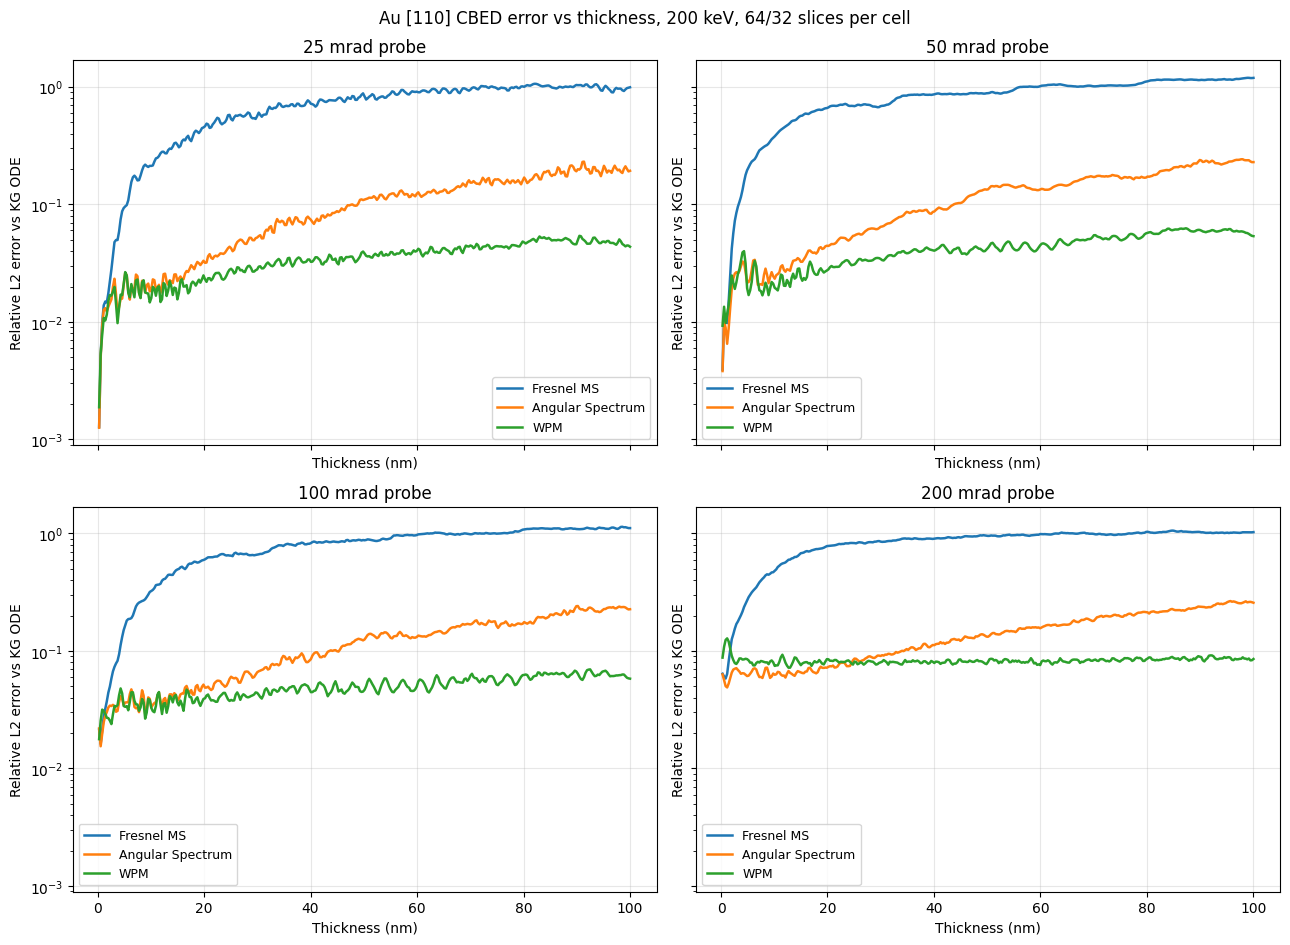

In [54]:
plot_methods = method_names
colors = {"Fresnel MS": "C0", "Angular Spectrum": "C1", "WPM": "C2"}
markers = {"Fresnel MS": "o", "Angular Spectrum": "s", "WPM": "D"}

n_angles = len(PROBE_ANGLES_MRAD)
ncols = 2
nrows = int(np.ceil(n_angles / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.8 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)

for ax, alpha in zip(axes, PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    for method in plot_methods:
        ax.semilogy(
            cbed_results["thickness_nm"],
            angle_results["rel_l2"][method],
            color=colors[method],
            label=method,
            linewidth=1.8,
        )
    ax.set_title(f"{alpha:.0f} mrad probe")
    ax.set_xlabel("Thickness (nm)")
    ax.set_ylabel("Relative L2 error vs KG ODE")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

for ax in axes[n_angles:]:
    ax.axis("off")

fig.suptitle(
    f"Au [110] CBED error vs thickness, {energy/1e3:.0f} keV, "
    f"{ODE_SLICES_PER_CELL}/{TEST_SLICES_PER_CELL} slices per cell",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Error differences versus thickness

Signed differences between method error curves (relative L2 vs KG ODE) to highlight when one approximation is systematically better or worse than another.


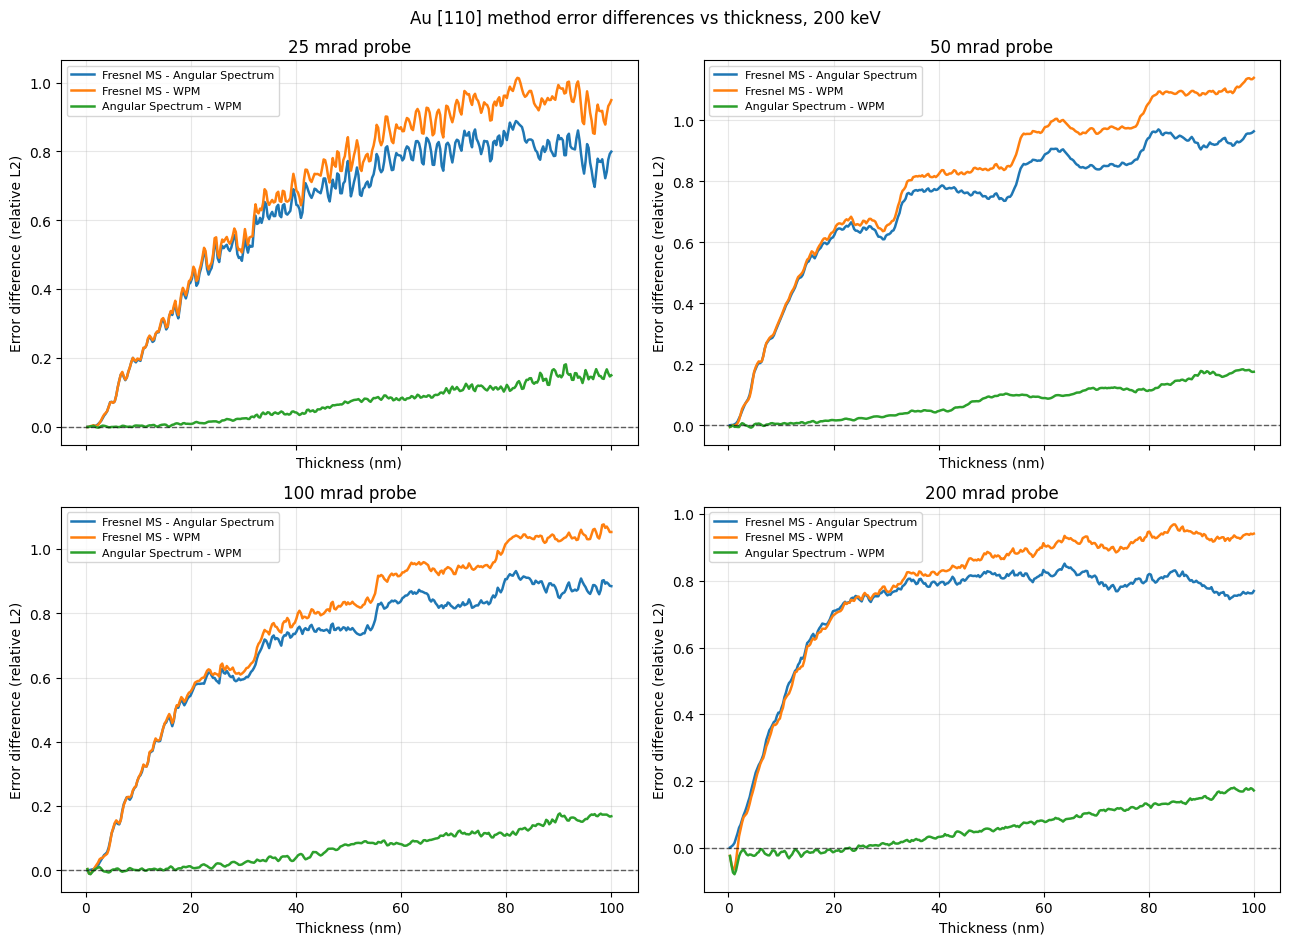

In [55]:
plot_methods = method_names
pairs = [
    ("Fresnel MS", "Angular Spectrum"),
    ("Fresnel MS", "WPM"),
    ("Angular Spectrum", "WPM"),
]
pairs = [pair for pair in pairs if pair[0] in plot_methods and pair[1] in plot_methods]

n_angles = len(PROBE_ANGLES_MRAD)
ncols = 2
nrows = int(np.ceil(n_angles / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.8 * nrows), sharex=True)
axes = np.asarray(axes).reshape(-1)

for ax, alpha in zip(axes, PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    for left, right in pairs:
        diff_curve = angle_results["rel_l2"][left] - angle_results["rel_l2"][right]
        ax.plot(
            cbed_results["thickness_nm"],
            diff_curve,
            linewidth=1.8,
            label=f"{left} - {right}",
        )
    ax.axhline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    ax.set_title(f"{alpha:.0f} mrad probe")
    ax.set_xlabel("Thickness (nm)")
    ax.set_ylabel("Error difference (relative L2)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

for ax in axes[n_angles:]:
    ax.axis("off")

fig.suptitle(
    f"Au [110] method error differences vs thickness, {energy/1e3:.0f} keV",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Central-ring error versus thickness

The central-ring mask is an annulus around the edge of the bright-field disk, scaled separately for each probe semi-angle.

In [56]:
has_central_ring_curves = all(
    np.isfinite(cbed_results["angles"][float(alpha)]["central_ring_rel_l2"][method]).any()
    for alpha in PROBE_ANGLES_MRAD
    for method in method_names
)

if not has_central_ring_curves:
    print("Central-ring error curves are not present in the loaded results file.")
    print("Set RECOMPUTE_SIMULATION = True and rerun the propagation cell to generate them.")
else:
    plot_methods = method_names
    colors = {"Fresnel MS": "C0", "Angular Spectrum": "C1", "WPM": "C2"}

    n_angles = len(PROBE_ANGLES_MRAD)
    ncols = 2
    nrows = int(np.ceil(n_angles / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4.8 * nrows), sharex=True, sharey=True)
    axes = np.asarray(axes).reshape(-1)

    for ax, alpha in zip(axes, PROBE_ANGLES_MRAD):
        angle_results = cbed_results["angles"][float(alpha)]
        for method in plot_methods:
            ax.semilogy(
                cbed_results["thickness_nm"],
                angle_results["central_ring_rel_l2"][method],
                color=colors[method],
                label=method,
                linewidth=1.8,
            )
        inner = CENTRAL_RING_INNER_FRACTION * alpha
        outer = CENTRAL_RING_OUTER_FRACTION * alpha
        ax.set_title(f"{alpha:.0f} mrad probe, {inner:.0f}-{outer:.0f} mrad annulus")
        ax.set_xlabel("Thickness (nm)")
        ax.set_ylabel("Central-ring relative L2 error")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)

    for ax in axes[n_angles:]:
        ax.axis("off")

    fig.suptitle(
        f"Au [110] central-ring CBED error vs thickness, {energy/1e3:.0f} keV",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


Central-ring error curves are not present in the loaded results file.
Set RECOMPUTE_SIMULATION = True and rerun the propagation cell to generate them.


## Central-cutoff CBED images

All CBED image panels use the same angular window around zero scattering angle, set by `CENTRAL_VIEW_CUTOFF_MRAD`.


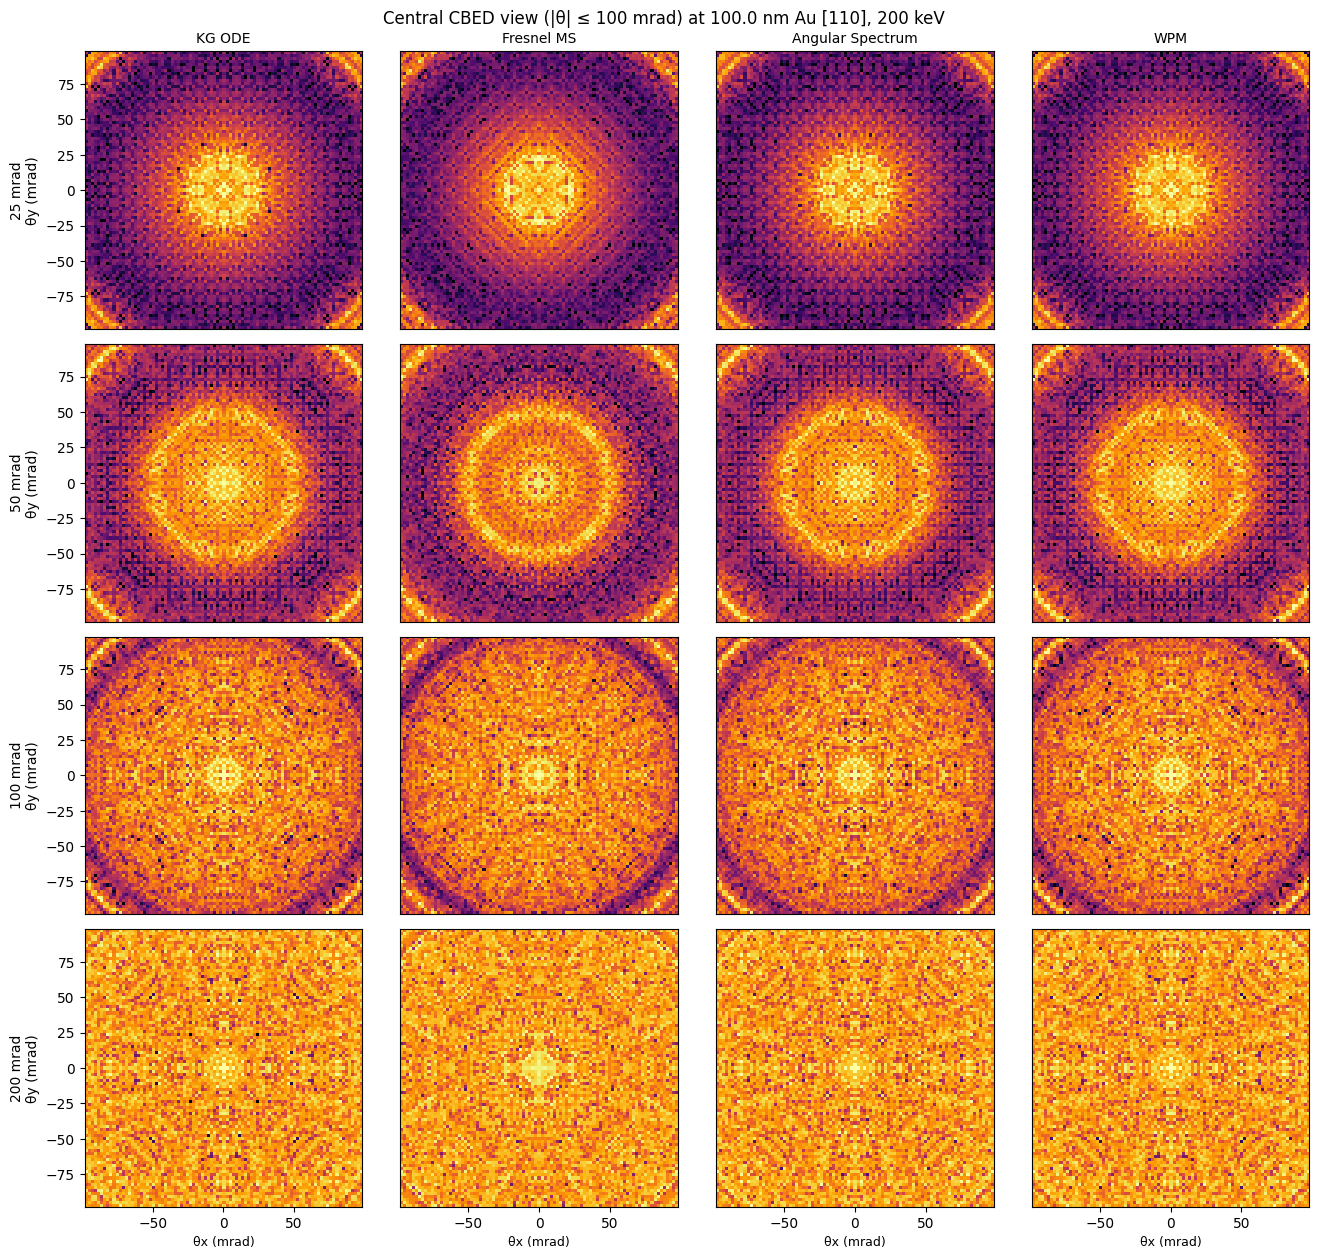

In [57]:
pattern_columns = ["KG ODE", *method_names]
nrows = len(PROBE_ANGLES_MRAD)
ncols = len(pattern_columns)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.2 * nrows))
axes = np.asarray(axes).reshape(nrows, ncols)

for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD,
        ny_g,
        nx_g,
        sampling[0],
        sampling[1],
        wavelength,
    )
    reference_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    positive = reference_crop[reference_crop > 0]
    vmax = float(np.percentile(reference_crop, 99.8))
    vmin = float(max(vmax * 1e-5, positive.min())) if positive.size else max(vmax * 1e-5, 1e-30)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]

    for col, name in enumerate(pattern_columns):
        dp_crop = angle_results["final_patterns"][name][y_slice, x_slice]
        axes[row, col].imshow(
            dp_crop,
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap="inferno",
            origin="lower",
            extent=extent,
        )
        if row == 0:
            axes[row, col].set_title(name, fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(f"{alpha:.0f} mrad\nθy (mrad)", fontsize=10)
        else:
            axes[row, col].set_yticks([])
        if row == nrows - 1:
            axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
        else:
            axes[row, col].set_xticks([])

fig.suptitle(
    f"Central CBED view (|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad) at {actual_thickness_nm:.1f} nm Au [110], {energy/1e3:.0f} keV",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Pixel-wise Amplitude Difference Maps (Method vs KG ODE)

Final-thickness CBED maps showing absolute percent amplitude error relative to KG ODE in the same central angular window.

For each pixel: $100 \times \left| |\psi_{\mathrm{method}}| - |\psi_{\mathrm{ODE}}| \right| / |\psi_{\mathrm{ODE}}|$.


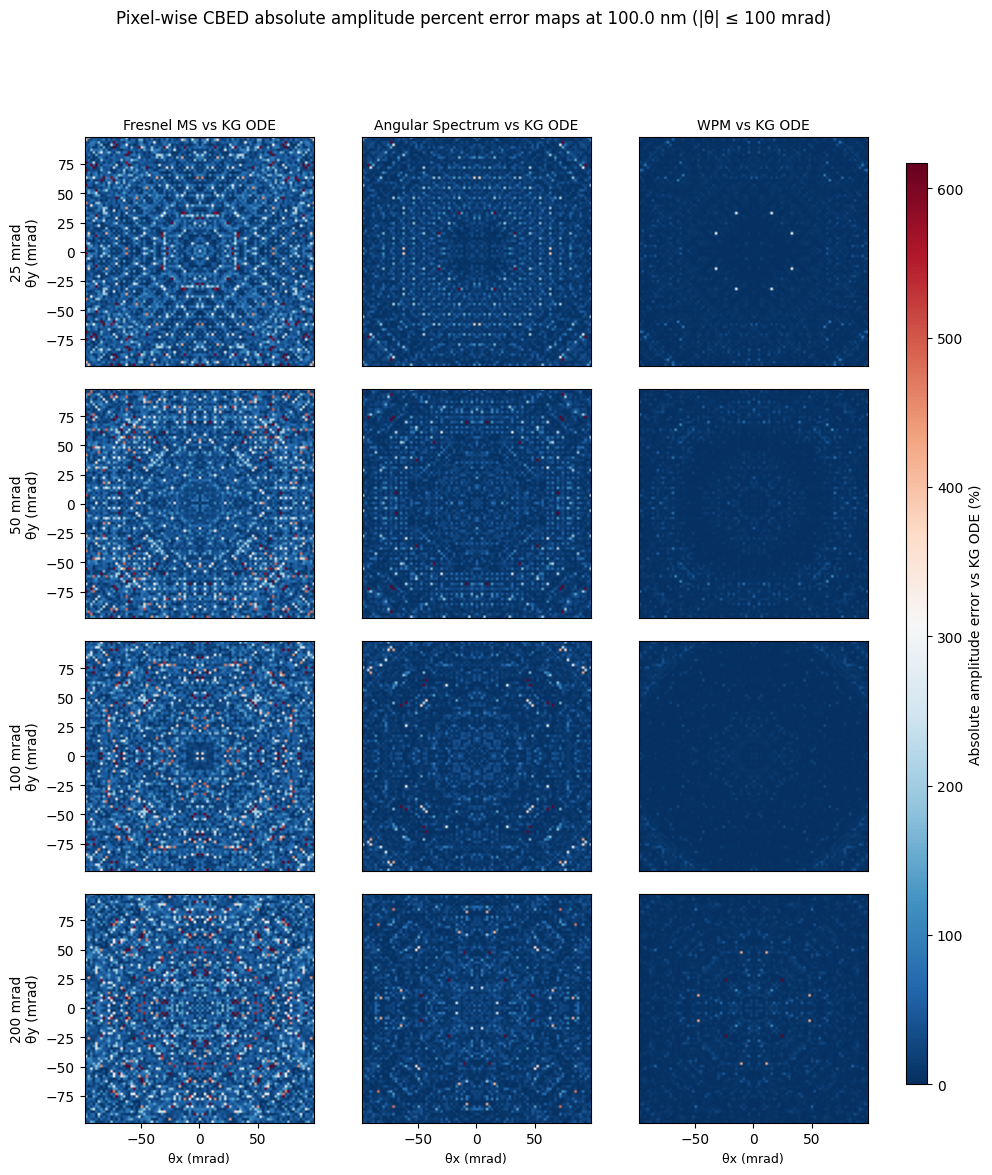

In [58]:
compare_methods = [name for name in method_names if name != "KG ODE"]
pattern_nrows = len(PROBE_ANGLES_MRAD)
pattern_ncols = len(compare_methods)
fig, axes = plt.subplots(
    pattern_nrows,
    pattern_ncols,
    figsize=(3.6 * pattern_ncols, 3.2 * pattern_nrows),
)
axes = np.asarray(axes).reshape(pattern_nrows, pattern_ncols)

# Build all absolute percent-amplitude errors first for one shared color scale.
all_errors_pct = []
for alpha in PROBE_ANGLES_MRAD:
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD,
        ny_g,
        nx_g,
        sampling[0],
        sampling[1],
        wavelength,
    )
    ode_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    amp_ode = np.sqrt(np.maximum(ode_crop, 0.0))
    for method in compare_methods:
        method_crop = angle_results["final_patterns"][method][y_slice, x_slice]
        amp_method = np.sqrt(np.maximum(method_crop, 0.0))
        err_pct = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
        all_errors_pct.append(err_pct)

if all_errors_pct:
    flat = np.concatenate([arr.ravel() for arr in all_errors_pct])
    vmax = float(np.percentile(np.abs(flat), 99.5))
else:
    vmax = 1.0
if vmax <= 0:
    vmax = 1.0
norm = None

im = None
for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD,
        ny_g,
        nx_g,
        sampling[0],
        sampling[1],
        wavelength,
    )
    ode_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    amp_ode = np.sqrt(np.maximum(ode_crop, 0.0))
    extent = [
        theta_x[x_slice.start],
        theta_x[x_slice.stop - 1],
        theta_y[y_slice.start],
        theta_y[y_slice.stop - 1],
    ]

    for col, method in enumerate(compare_methods):
        method_crop = angle_results["final_patterns"][method][y_slice, x_slice]
        amp_method = np.sqrt(np.maximum(method_crop, 0.0))
        err_pct = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
        im = axes[row, col].imshow(
            err_pct,
            cmap="RdBu_r",
            vmin=0.0,
            vmax=vmax,
            origin="lower",
            extent=extent,
        )
        if row == 0:
            axes[row, col].set_title(f"{method} vs KG ODE", fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(
                f"{alpha:.0f} mrad\nθy (mrad)",
                fontsize=10,
            )
        else:
            axes[row, col].set_yticks([])
        if row == pattern_nrows - 1:
            axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
        else:
            axes[row, col].set_xticks([])

# Reserve right margin and place one shared colorbar aligned with panel stack.
fig.subplots_adjust(right=0.88, wspace=0.06, hspace=0.10)
cax = fig.add_axes([0.90, 0.14, 0.02, 0.72])
if im is not None:
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label("Absolute amplitude error vs KG ODE (%)")

fig.suptitle(
    f"Pixel-wise CBED absolute amplitude percent error maps at {actual_thickness_nm:.1f} nm "
    f"(|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad)",
    fontsize=12,
)
plt.show()


Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_combined_amplitude_log_error_maps.pdf


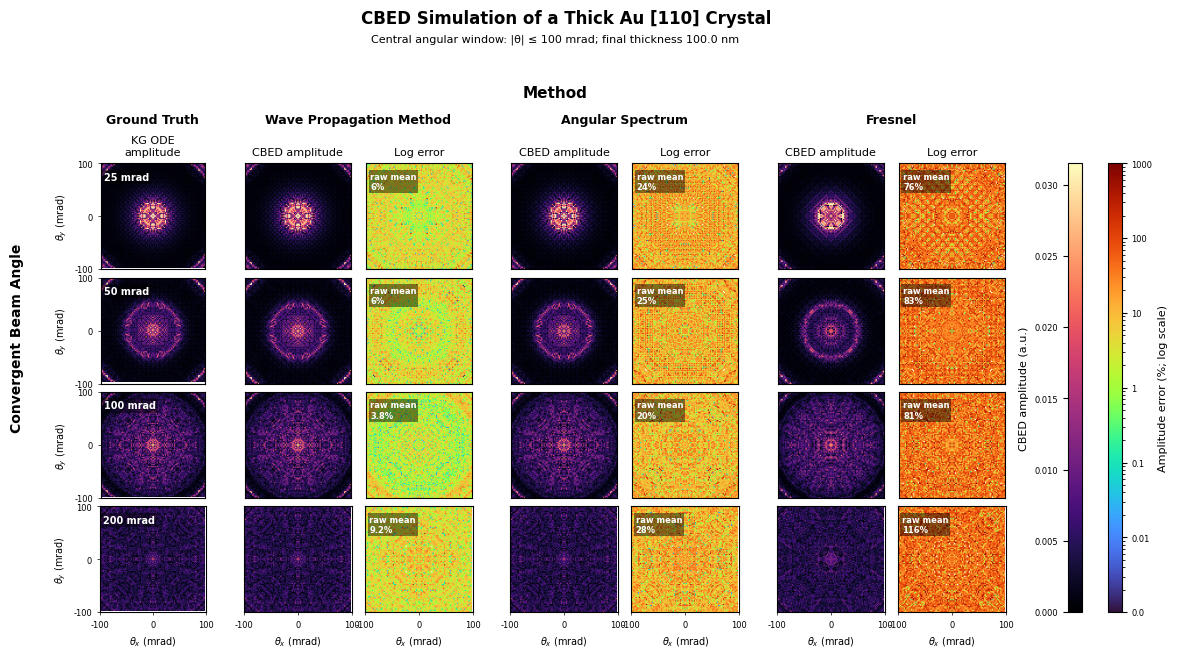

In [65]:
# Paper-ready combined raw CBED amplitude + log amplitude-error map figure
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm, Normalize

# ---------------------------------------------------------------------
# User-tunable figure controls
# ---------------------------------------------------------------------
# Data/export controls.
RESULTS_FILENAME = globals().get("RESULTS_FILENAME", "cbed_thickness_series_au110_100nm.npz")
COMBINED_OUTPUT_FILENAME = "cbed_combined_amplitude_log_error_maps.pdf"
CENTRAL_VIEW_CUTOFF_MRAD = globals().get("CENTRAL_VIEW_CUTOFF_MRAD", 100.0)
THETA_AXIS_TICKS = [-CENTRAL_VIEW_CUTOFF_MRAD, 0.0, CENTRAL_VIEW_CUTOFF_MRAD]
THETA_AXIS_TICK_LABELS = [f"-{CENTRAL_VIEW_CUTOFF_MRAD:.0f}", "0", f"{CENTRAL_VIEW_CUTOFF_MRAD:.0f}"]
THETA_X_AXIS_LABEL = r"$\theta_x$ (mrad)"
THETA_Y_AXIS_LABEL = r"$\theta_y$ (mrad)"
METHOD_PLOT_ORDER = ["WPM", "Angular Spectrum", "Fresnel MS"]
METHOD_DISPLAY_LABELS = {
    "WPM": "Wave Propagation Method",
    "Angular Spectrum": "Angular Spectrum",
    "Fresnel MS": "Fresnel",
}

# Color-scale controls.
AMPLITUDE_CMAP = "magma"
# Error colormap for quick visual comparison experiments.
# Alternatives worth trying: "cividis", "viridis", "turbo", "magma".
ERROR_CMAP = "turbo"
AMPLITUDE_VMAX_PERCENTILE = 99.8
ERROR_FLOOR_PCT = 1e-3
ERROR_VMAX_PERCENTILE = 99.5
ERROR_MIN_POSITIVE_PCT = 1e-12
ERROR_COLORBAR_MIN = 1e-3
ERROR_COLORBAR_MAX = 1e3
ERROR_COLORBAR_EXTEND = "neither"
ERROR_COLORBAR_EXTEND_FRAC = 0.06
ERROR_COLORBAR_UNDER_OVER_COLOR = "white"
ERROR_COLORBAR_TICKS = [ERROR_COLORBAR_MIN, 1e-2, 1e-1, 1.0, 10.0, 100.0, ERROR_COLORBAR_MAX]
ERROR_COLORBAR_TICK_LABELS = ["0.0", "0.01", "0.1", "1", "10", "100", "1000"]

# Figure size and grid spacing. Coordinates below are figure fractions.
COMBINED_FIGSIZE = (11.4, 6.7)
GRID_PANEL_WIDTH = 1.0
METHOD_BLOCK_SPACER_WIDTH = 0.18
SUBPLOT_LEFT = 0.085
SUBPLOT_RIGHT = 0.89
SUBPLOT_BOTTOM = 0.09
SUBPLOT_TOP = 0.76
SUBPLOT_WSPACE = 0.03
SUBPLOT_HSPACE = 0.08

# Header, group label, and outer label positions.
HEADER_X = 0.49
SUPTITLE_Y = 0.990
CENTRAL_WINDOW_TEXT_Y = 0.945
METHOD_LABEL_Y = 0.865
METHOD_GROUP_LABEL_Y = 0.825
LEFT_OUTER_LABEL_X = 0.018
LEFT_OUTER_LABEL_Y = 0.50

# In-panel annotation positions and padding.
ANGLE_LABEL_X = 0.03
ANGLE_LABEL_Y = 0.92
ERROR_SUMMARY_LABEL_X = 0.04
ERROR_SUMMARY_LABEL_Y = 0.92
INSET_LABEL_BBOX_ALPHA = 0.45
ANGLE_LABEL_BBOX_PAD = 1.5
ERROR_SUMMARY_LABEL_BBOX_PAD = 1.2

# Colorbar placement.
COLORBAR_WIDTH = 0.012
AMPLITUDE_COLORBAR_X = 0.940
ERROR_COLORBAR_X = 0.975

# Typography and tick styling.
SUPTITLE_FONTSIZE = 12
HEADER_FONTSIZE = 8
METHOD_LABEL_FONTSIZE = 11
METHOD_GROUP_FONTSIZE = 9
LEFT_OUTER_LABEL_FONTSIZE = 10
PANEL_TITLE_FONTSIZE = 8
AXIS_LABEL_FONTSIZE = 7
AXIS_TICK_LABELSIZE = 6
AXIS_TICK_LENGTH = 2
AXIS_TICK_WIDTH = 0.5
ANGLE_LABEL_FONTSIZE = 7
ERROR_SUMMARY_FONTSIZE = 6
COLORBAR_LABEL_FONTSIZE = 8
COLORBAR_TICK_LABELSIZE = 6


def _combined_resolve_repo_root():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / "notebooks").exists() and (base / "Paper").exists():
            return base
    return cwd


if "diffraction_angle_axes_mrad" not in globals():
    def diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang):
        fy = np.fft.fftshift(np.fft.fftfreq(ny, d=samp_y))
        fx = np.fft.fftshift(np.fft.fftfreq(nx, d=samp_x))
        theta_y = 1e3 * np.arcsin(np.clip(wavelength_ang * fy, -1.0, 1.0))
        theta_x = 1e3 * np.arcsin(np.clip(wavelength_ang * fx, -1.0, 1.0))
        return theta_y, theta_x


if "central_crop_slices_by_cutoff" not in globals():
    def central_crop_slices_by_cutoff(cutoff_mrad, ny, nx, samp_y, samp_x, wavelength_ang):
        theta_y, theta_x = diffraction_angle_axes_mrad(ny, nx, samp_y, samp_x, wavelength_ang)
        y_idx = np.where(np.abs(theta_y) <= cutoff_mrad)[0]
        x_idx = np.where(np.abs(theta_x) <= cutoff_mrad)[0]
        if y_idx.size == 0 or x_idx.size == 0:
            raise ValueError(f"No central crop pixels for cutoff {cutoff_mrad} mrad")
        return slice(y_idx[0], y_idx[-1] + 1), slice(x_idx[0], x_idx[-1] + 1), theta_y, theta_x


_required_result_names = (
    "method_names",
    "PROBE_ANGLES_MRAD",
    "cbed_results",
    "gpts",
    "sampling",
    "ny_g",
    "nx_g",
    "wavelength",
    "actual_thickness_nm",
)
if any(name not in globals() for name in _required_result_names):
    results_path = _combined_resolve_repo_root() / "notebooks" / "cbed" / "results" / RESULTS_FILENAME
    if not results_path.exists():
        raise FileNotFoundError(f"Could not find saved CBED results: {results_path}")

    with np.load(results_path, allow_pickle=True) as data:
        method_names = [str(name) for name in data["method_names"]]
        PROBE_ANGLES_MRAD = data["probe_angles_mrad"].astype(float)
        gpts = tuple(int(value) for value in data["gpts"])
        sampling = tuple(float(value) for value in data["sampling_A"])
        ny_g, nx_g = gpts
        metadata = dict(data["metadata"][0])
        wavelength = float(metadata["wavelength_A"])
        actual_thickness_nm = float(metadata["actual_thickness_nm"])
        cbed_results = {
            "metadata": metadata,
            "thickness_nm": data["thickness_nm"].copy(),
            "angles": {},
        }
        for alpha in PROBE_ANGLES_MRAD:
            angle_key = f"angle_{alpha:.0f}mrad"
            angle_results = {
                "final_patterns": {
                    "KG ODE": data[f"{angle_key}_kg_ode_final_pattern"].copy(),
                },
            }
            for method in method_names:
                method_key = method.lower().replace(" ", "_")
                angle_results["final_patterns"][method] = data[f"{angle_key}_{method_key}_final_pattern"].copy()
            cbed_results["angles"][float(alpha)] = angle_results

ordered_compare_methods = [method for method in METHOD_PLOT_ORDER if method in method_names and method != "KG ODE"]
remaining_compare_methods = [name for name in method_names if name != "KG ODE" and name not in ordered_compare_methods]
compare_methods = ordered_compare_methods + remaining_compare_methods

# Build cropped panels and shared color scales before drawing the figure.
panel_cache = {}
amplitude_values = []
error_values = []

for alpha in PROBE_ANGLES_MRAD:
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD,
        ny_g,
        nx_g,
        sampling[0],
        sampling[1],
        wavelength,
    )
    extent = [
        theta_x[x_slice.start],
        theta_x[x_slice.stop - 1],
        theta_y[y_slice.start],
        theta_y[y_slice.stop - 1],
    ]
    reference_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    amp_ode = np.sqrt(np.maximum(reference_crop, 0.0))

    panel_cache[float(alpha)] = {
        "extent": extent,
        "amplitude": {"KG ODE": amp_ode},
        "error_pct": {},
    }
    amplitude_values.append(amp_ode[amp_ode > 0])

    for method in compare_methods:
        method_crop = angle_results["final_patterns"][method][y_slice, x_slice]
        amp_method = np.sqrt(np.maximum(method_crop, 0.0))
        err_pct = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
        panel_cache[float(alpha)]["amplitude"][method] = amp_method
        panel_cache[float(alpha)]["error_pct"][method] = err_pct
        amplitude_values.append(amp_method[amp_method > 0])
        error_values.append(err_pct[err_pct > 0])

amp_nonempty = [values.ravel() for values in amplitude_values if values.size]
amp_flat = np.concatenate(amp_nonempty) if amp_nonempty else np.array([1.0])
amplitude_vmax = float(np.percentile(amp_flat, AMPLITUDE_VMAX_PERCENTILE))
if amplitude_vmax <= 0:
    amplitude_vmax = 1.0
amplitude_norm = Normalize(vmin=0.0, vmax=amplitude_vmax)

error_nonempty = [values.ravel() for values in error_values if values.size]
error_flat = np.concatenate(error_nonempty) if error_nonempty else np.array([ERROR_FLOOR_PCT])
error_data_max = float(np.percentile(error_flat, ERROR_VMAX_PERCENTILE))
if error_data_max <= 0.0:
    error_data_max = ERROR_COLORBAR_MIN
error_norm = LogNorm(vmin=ERROR_COLORBAR_MIN, vmax=ERROR_COLORBAR_MAX)
error_cmap_obj = plt.get_cmap(ERROR_CMAP).copy()
error_cmap_obj.set_under(ERROR_COLORBAR_UNDER_OVER_COLOR)
error_cmap_obj.set_over(ERROR_COLORBAR_UNDER_OVER_COLOR)


def _combined_error_summary_label(error_pct):
    values = np.asarray(error_pct)
    values = values[np.isfinite(values)]
    if values.size == 0:
        return "raw mean\nn/a"
    raw_mean = float(np.mean(values))
    if raw_mean < 0.01:
        value_text = f"{raw_mean:.1e}%"
    elif raw_mean < 1.0:
        value_text = f"{raw_mean:.2f}%"
    elif raw_mean < 10.0:
        value_text = f"{raw_mean:.2g}%"
    elif raw_mean < 1000.0:
        value_text = f"{raw_mean:.0f}%"
    else:
        value_text = f"{raw_mean:.1e}%"
    return f"raw mean\n{value_text}"


nrows = len(PROBE_ANGLES_MRAD)
groups = [("Ground Truth", ["KG ODE"])] + [(METHOD_DISPLAY_LABELS.get(method, method), [f"{method} amplitude", f"{method} error"]) for method in compare_methods]
width_ratios = []
grid_columns = []
for group_index, (_, columns) in enumerate(groups):
    if group_index > 0:
        grid_columns.append(("spacer", None))
        width_ratios.append(METHOD_BLOCK_SPACER_WIDTH)
    for column in columns:
        grid_columns.append(("panel", column))
        width_ratios.append(GRID_PANEL_WIDTH)

fig, grid_axes = plt.subplots(
    nrows,
    len(grid_columns),
    figsize=COMBINED_FIGSIZE,
    gridspec_kw={"width_ratios": width_ratios},
)
grid_axes = np.asarray(grid_axes).reshape(nrows, len(grid_columns))
panel_axes = {column: grid_axes[:, index] for index, (kind, column) in enumerate(grid_columns) if kind == "panel"}

for index, (kind, _) in enumerate(grid_columns):
    if kind == "spacer":
        for ax in grid_axes[:, index]:
            ax.axis("off")

amplitude_im = None
error_im = None
for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    alpha_key = float(alpha)
    extent = panel_cache[alpha_key]["extent"]

    amplitude_im = panel_axes["KG ODE"][row].imshow(
        panel_cache[alpha_key]["amplitude"]["KG ODE"],
        norm=amplitude_norm,
        cmap=AMPLITUDE_CMAP,
        origin="lower",
        extent=extent,
    )
    panel_axes["KG ODE"][row].text(
        ANGLE_LABEL_X,
        ANGLE_LABEL_Y,
        f"{alpha:.0f} mrad",
        transform=panel_axes["KG ODE"][row].transAxes,
        ha="left",
        va="top",
        color="white",
        fontsize=ANGLE_LABEL_FONTSIZE,
        fontweight="bold",
        bbox={"facecolor": "black", "alpha": INSET_LABEL_BBOX_ALPHA, "edgecolor": "none", "pad": ANGLE_LABEL_BBOX_PAD},
    )

    for method in compare_methods:
        amplitude_column = f"{method} amplitude"
        error_column = f"{method} error"
        amplitude_im = panel_axes[amplitude_column][row].imshow(
            panel_cache[alpha_key]["amplitude"][method],
            norm=amplitude_norm,
            cmap=AMPLITUDE_CMAP,
            origin="lower",
            extent=extent,
        )
        error_im = panel_axes[error_column][row].imshow(
            np.maximum(panel_cache[alpha_key]["error_pct"][method], ERROR_MIN_POSITIVE_PCT),
            norm=error_norm,
            cmap=error_cmap_obj,
            origin="lower",
            extent=extent,
        )
        panel_axes[error_column][row].text(
            ERROR_SUMMARY_LABEL_X,
            ERROR_SUMMARY_LABEL_Y,
            _combined_error_summary_label(panel_cache[alpha_key]["error_pct"][method]),
            transform=panel_axes[error_column][row].transAxes,
            ha="left",
            va="top",
            color="white",
            fontsize=ERROR_SUMMARY_FONTSIZE,
            fontweight="bold",
            bbox={"facecolor": "black", "alpha": INSET_LABEL_BBOX_ALPHA, "edgecolor": "none", "pad": ERROR_SUMMARY_LABEL_BBOX_PAD},
        )

    for column_index, (kind, column) in enumerate(grid_columns):
        if kind != "panel":
            continue
        ax = grid_axes[row, column_index]
        ax.tick_params(labelsize=AXIS_TICK_LABELSIZE, length=AXIS_TICK_LENGTH, width=AXIS_TICK_WIDTH)
        if row != nrows - 1:
            ax.set_xticks([])
        else:
            ax.set_xticks(THETA_AXIS_TICKS, THETA_AXIS_TICK_LABELS)
            ax.set_xlabel(THETA_X_AXIS_LABEL, fontsize=AXIS_LABEL_FONTSIZE)
        if column != "KG ODE":
            ax.set_yticks([])
        else:
            ax.set_yticks(THETA_AXIS_TICKS, THETA_AXIS_TICK_LABELS)
            ax.set_ylabel(THETA_Y_AXIS_LABEL, fontsize=AXIS_LABEL_FONTSIZE)

panel_axes["KG ODE"][0].set_title("KG ODE\namplitude", fontsize=PANEL_TITLE_FONTSIZE)
for method in compare_methods:
    panel_axes[f"{method} amplitude"][0].set_title("CBED amplitude", fontsize=PANEL_TITLE_FONTSIZE)
    panel_axes[f"{method} error"][0].set_title("Log error", fontsize=PANEL_TITLE_FONTSIZE)

fig.subplots_adjust(
    left=SUBPLOT_LEFT,
    right=SUBPLOT_RIGHT,
    bottom=SUBPLOT_BOTTOM,
    top=SUBPLOT_TOP,
    wspace=SUBPLOT_WSPACE,
    hspace=SUBPLOT_HSPACE,
)
fig.suptitle("CBED Simulation of a Thick Au [110] Crystal", y=SUPTITLE_Y, fontsize=SUPTITLE_FONTSIZE, fontweight="bold")
fig.text(
    HEADER_X,
    CENTRAL_WINDOW_TEXT_Y,
    f"Central angular window: |θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad; final thickness {actual_thickness_nm:.1f} nm",
    ha="center",
    va="center",
    fontsize=HEADER_FONTSIZE,
)
fig.text(HEADER_X, METHOD_LABEL_Y, "Method", ha="center", va="center", fontsize=METHOD_LABEL_FONTSIZE, fontweight="bold")
fig.text(LEFT_OUTER_LABEL_X, LEFT_OUTER_LABEL_Y, "Convergent Beam Angle", ha="center", va="center", rotation="vertical", fontsize=LEFT_OUTER_LABEL_FONTSIZE, fontweight="bold")

for group_label, columns in groups:
    positions = [panel_axes[column][0].get_position() for column in columns]
    left = min(position.x0 for position in positions)
    right = max(position.x1 for position in positions)
    fig.text((left + right) / 2.0, METHOD_GROUP_LABEL_Y, group_label, ha="center", va="center", fontsize=METHOD_GROUP_FONTSIZE, fontweight="bold")

def _combined_row_span(row_start, row_stop):
    row_positions = [panel_axes["KG ODE"][row].get_position() for row in range(row_start, row_stop)]
    return min(position.y0 for position in row_positions), max(position.y1 for position in row_positions)

colorbar_bottom, colorbar_top = _combined_row_span(0, nrows)
colorbar_height = colorbar_top - colorbar_bottom
if amplitude_im is not None:
    amplitude_cax = fig.add_axes([AMPLITUDE_COLORBAR_X, colorbar_bottom, COLORBAR_WIDTH, colorbar_height])
    amplitude_cbar = fig.colorbar(amplitude_im, cax=amplitude_cax)
    amplitude_cbar.set_label("CBED amplitude (a.u.)", fontsize=COLORBAR_LABEL_FONTSIZE)
    amplitude_cbar.ax.yaxis.set_ticks_position("left")
    amplitude_cbar.ax.yaxis.set_label_position("left")
    amplitude_cbar.ax.tick_params(labelsize=COLORBAR_TICK_LABELSIZE)
if error_im is not None:
    error_cax = fig.add_axes([ERROR_COLORBAR_X, colorbar_bottom, COLORBAR_WIDTH, colorbar_height])
    error_cbar = fig.colorbar(
        error_im,
        cax=error_cax,
        extend=ERROR_COLORBAR_EXTEND,
        extendfrac=ERROR_COLORBAR_EXTEND_FRAC,
    )
    error_cbar.set_label("Amplitude error (%; log scale)", fontsize=COLORBAR_LABEL_FONTSIZE)
    error_cbar.set_ticks(ERROR_COLORBAR_TICKS)
    error_cbar.ax.set_yticklabels(ERROR_COLORBAR_TICK_LABELS)
    error_cbar.ax.yaxis.set_ticks_position("right")
    error_cbar.ax.yaxis.set_label_position("right")
    error_cbar.ax.tick_params(labelsize=COLORBAR_TICK_LABELSIZE)

combined_fig_dir = _combined_resolve_repo_root() / "Paper" / "figures"
combined_fig_dir.mkdir(parents=True, exist_ok=True)
combined_path = combined_fig_dir / COMBINED_OUTPUT_FILENAME
fig.savefig(combined_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved -> {combined_path}")
plt.show()

## Final CBED pattern overview

This overview uses the same central angular cutoff as the previous grid so all image panels are directly comparable.


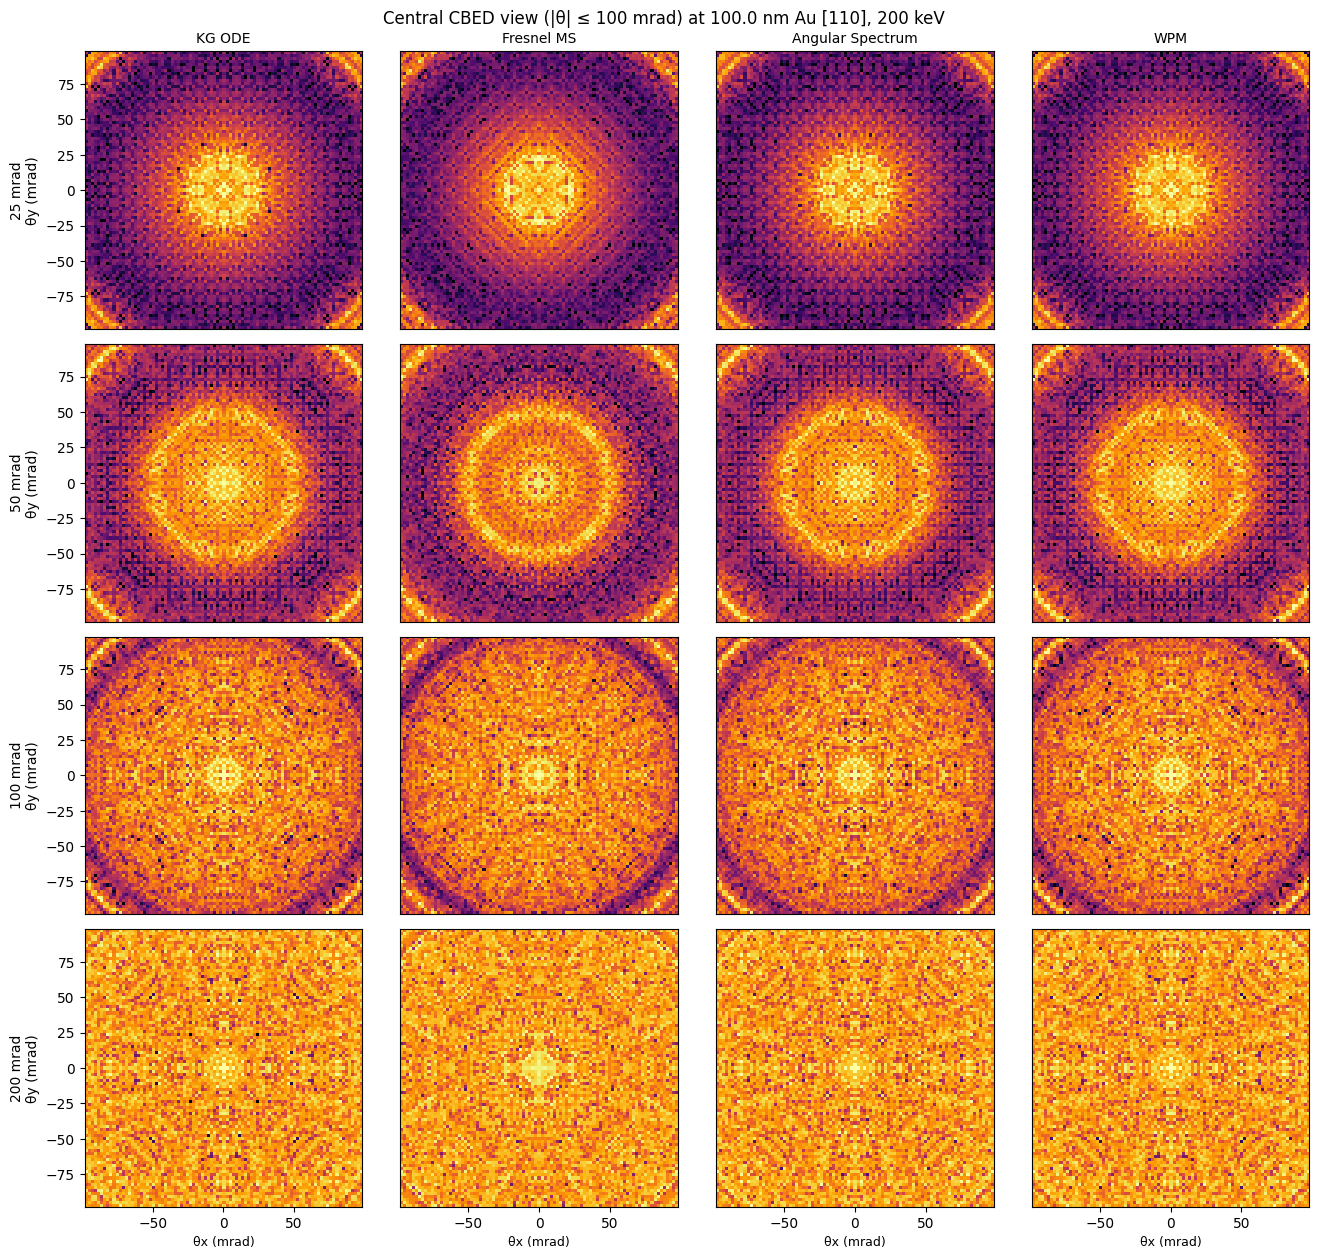

In [60]:
pattern_columns = ["KG ODE", *method_names]
nrows = len(PROBE_ANGLES_MRAD)
ncols = len(pattern_columns)
fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.2 * nrows))
axes = np.asarray(axes).reshape(nrows, ncols)

for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
        CENTRAL_VIEW_CUTOFF_MRAD,
        ny_g,
        nx_g,
        sampling[0],
        sampling[1],
        wavelength,
    )
    reference_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    positive = reference_crop[reference_crop > 0]
    vmax = float(np.percentile(reference_crop, 99.8))
    vmin = float(max(vmax * 1e-5, positive.min())) if positive.size else max(vmax * 1e-5, 1e-30)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]

    for col, name in enumerate(pattern_columns):
        dp_crop = angle_results["final_patterns"][name][y_slice, x_slice]
        axes[row, col].imshow(
            dp_crop,
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap="inferno",
            origin="lower",
            extent=extent,
        )
        if row == 0:
            axes[row, col].set_title(name, fontsize=10)
        if col == 0:
            axes[row, col].set_ylabel(f"{alpha:.0f} mrad\nθy (mrad)", fontsize=10)
        else:
            axes[row, col].set_yticks([])
        if row == nrows - 1:
            axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
        else:
            axes[row, col].set_xticks([])

fig.suptitle(
    f"Central CBED view (|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad) at {actual_thickness_nm:.1f} nm Au [110], {energy/1e3:.0f} keV",
    fontsize=12,
)
plt.tight_layout()
plt.show()


## Export figures

Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_error_vs_thickness.pdf
Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_error_differences_vs_thickness.pdf
Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_pixel_error_maps_vs_ode.pdf
Skipped central-ring error export: loaded results do not contain central-ring curves.
Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_final_pattern_grid.pdf
Saved -> /home/dl277493/Documents/Code/WideAnglePropagation/Paper/figures/cbed_final_central_zoom_grid.pdf


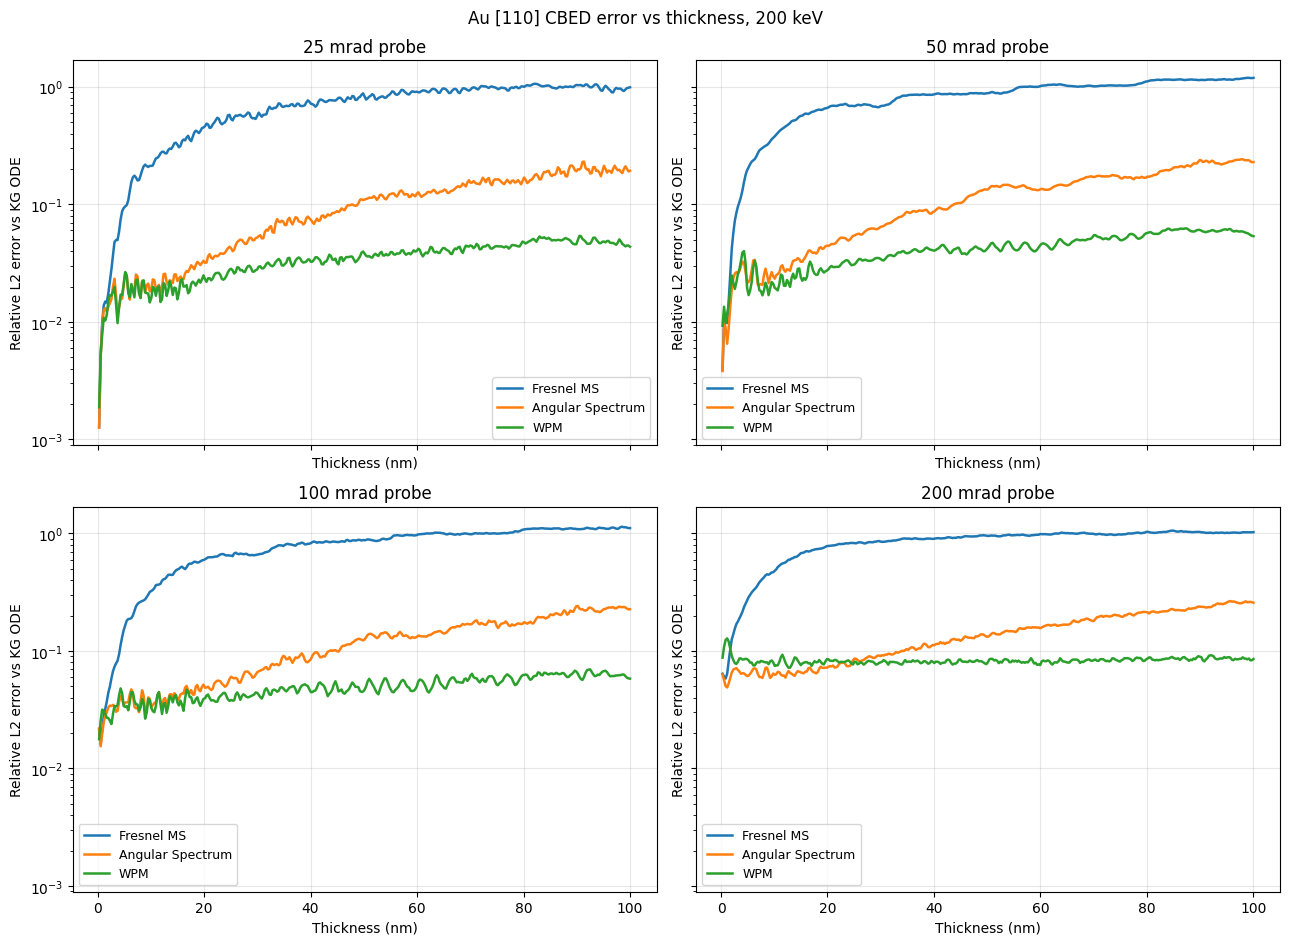

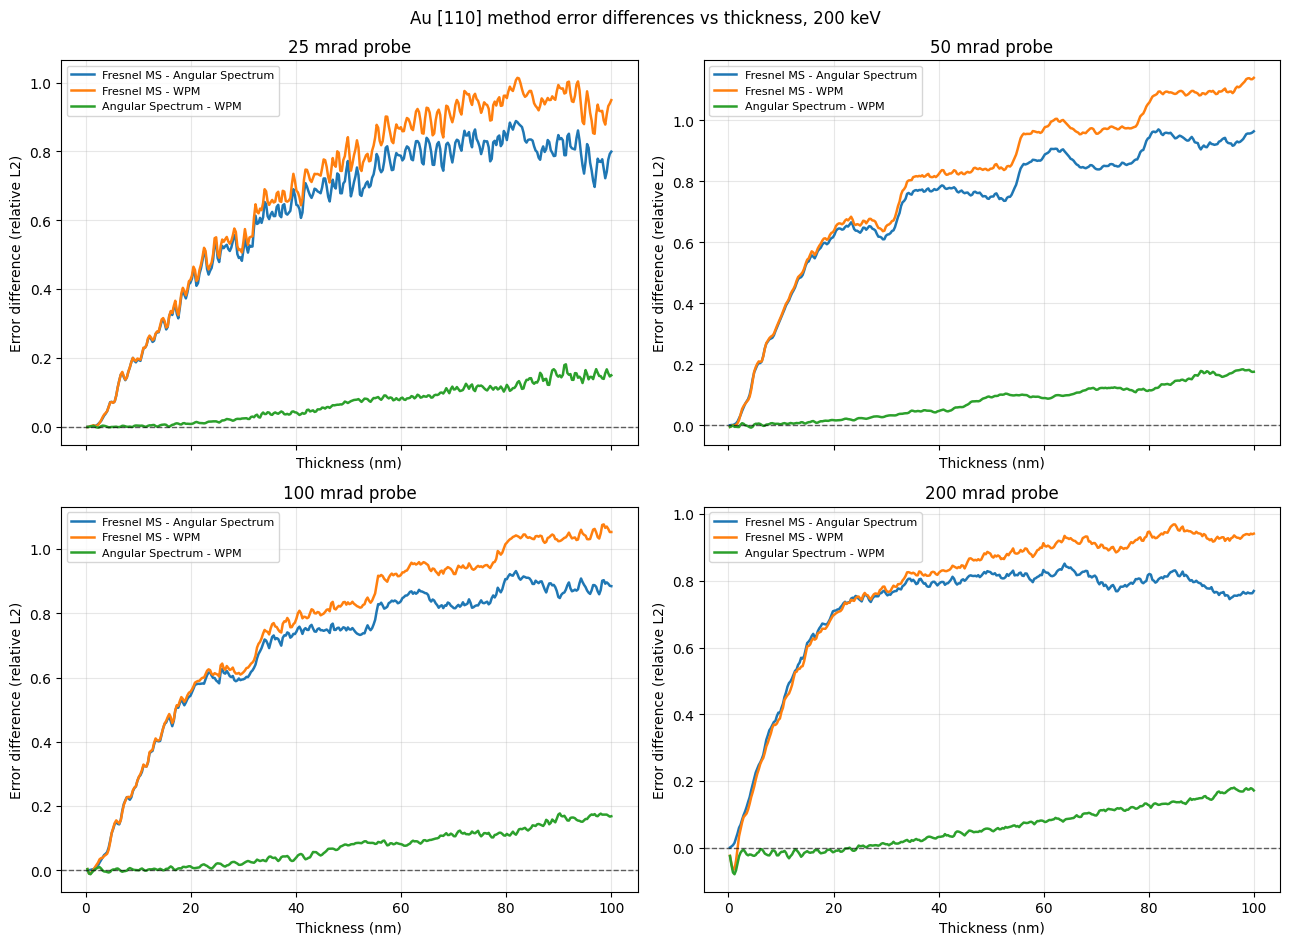

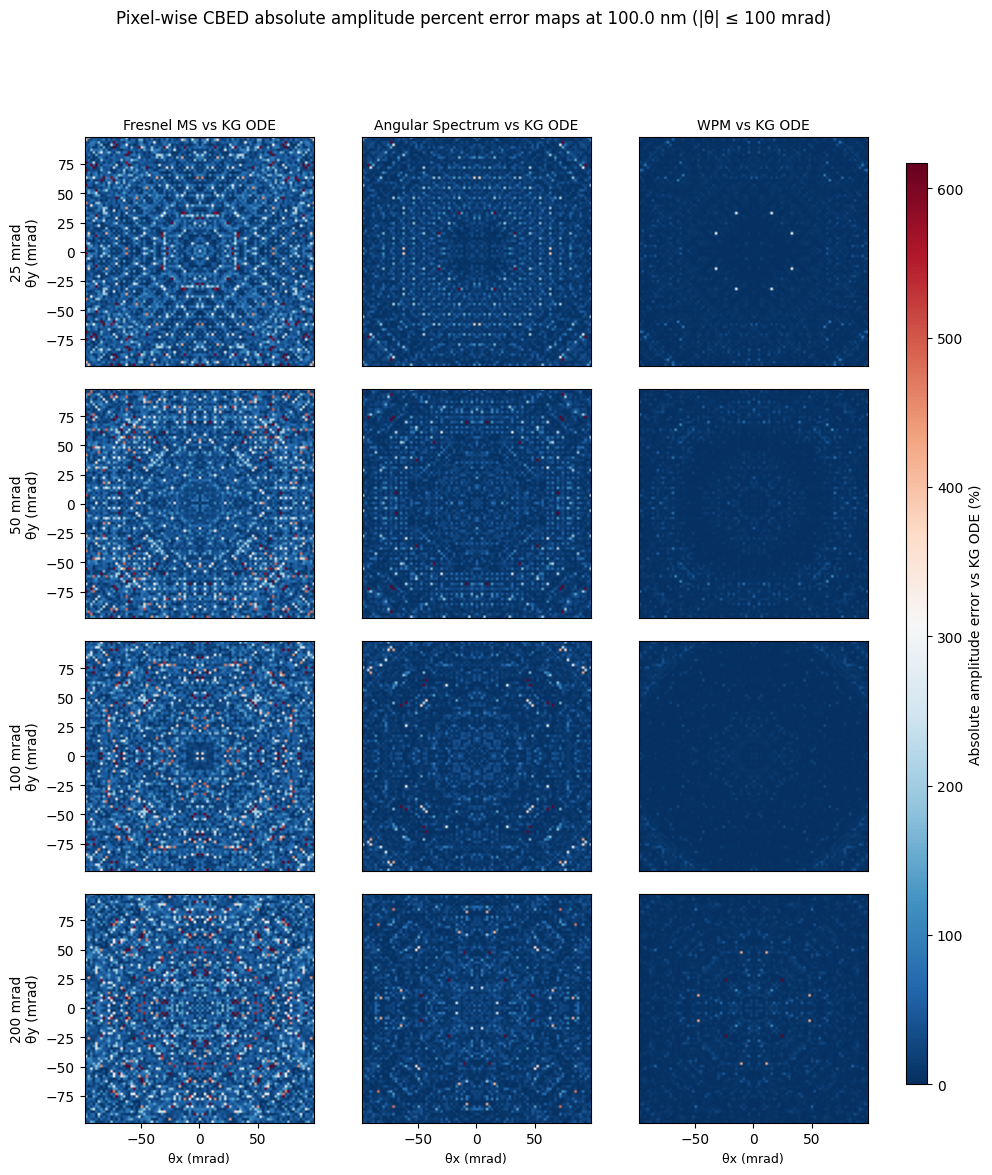

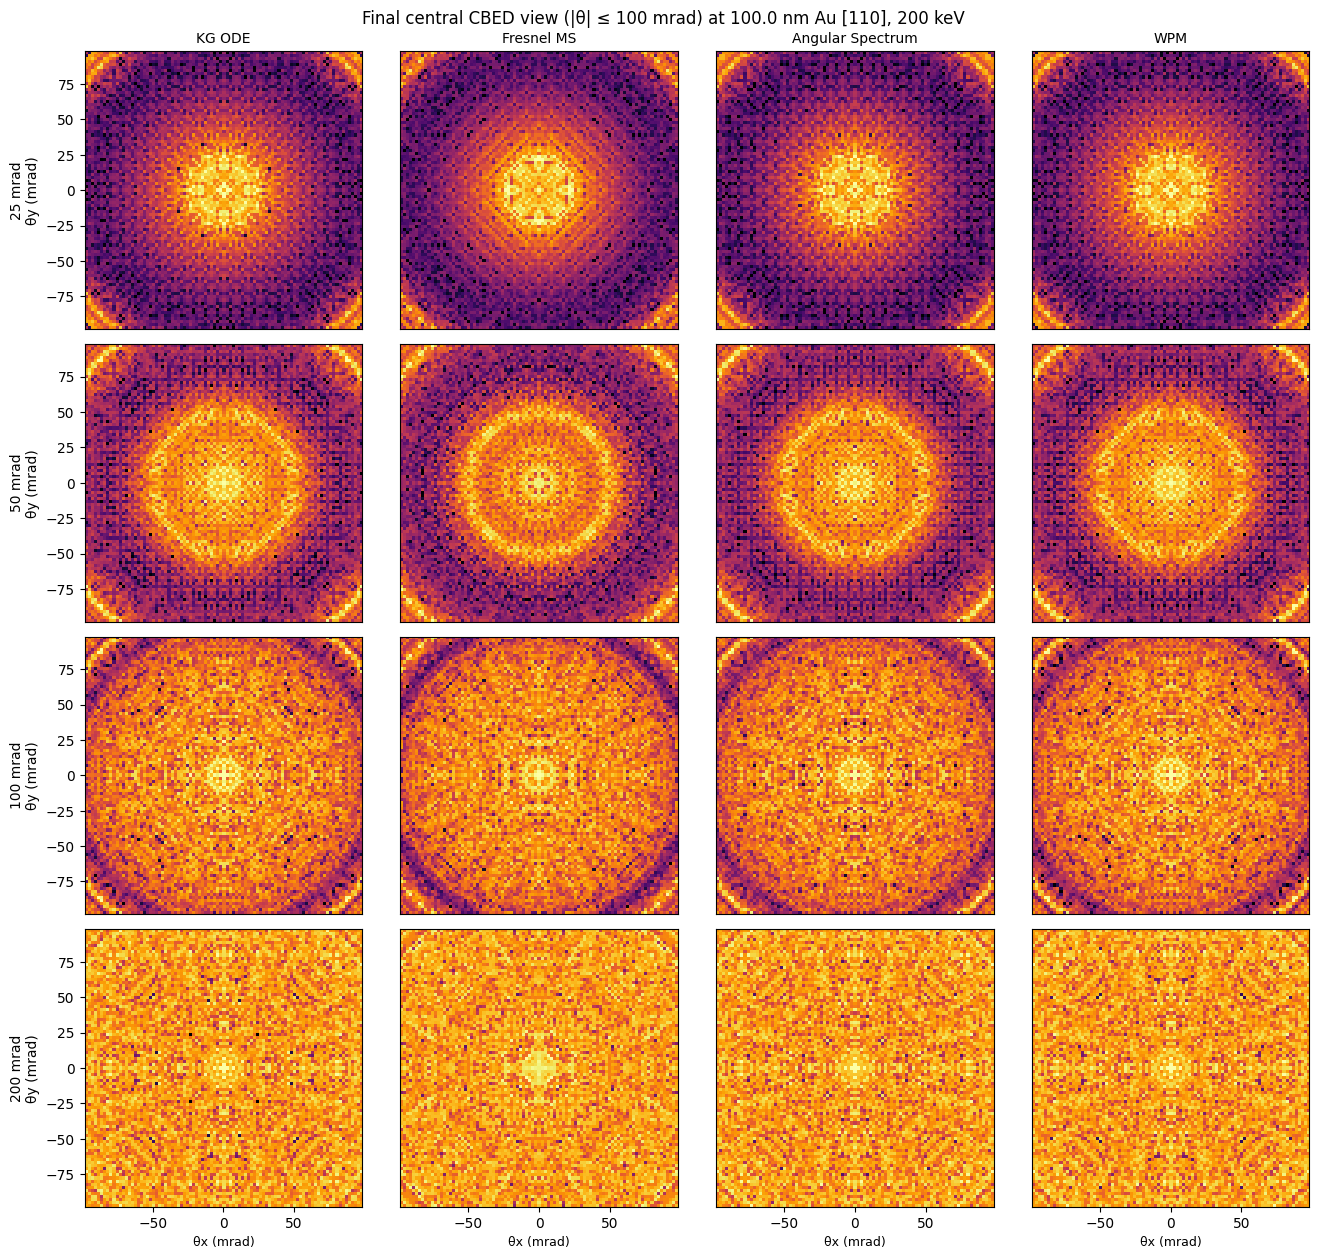

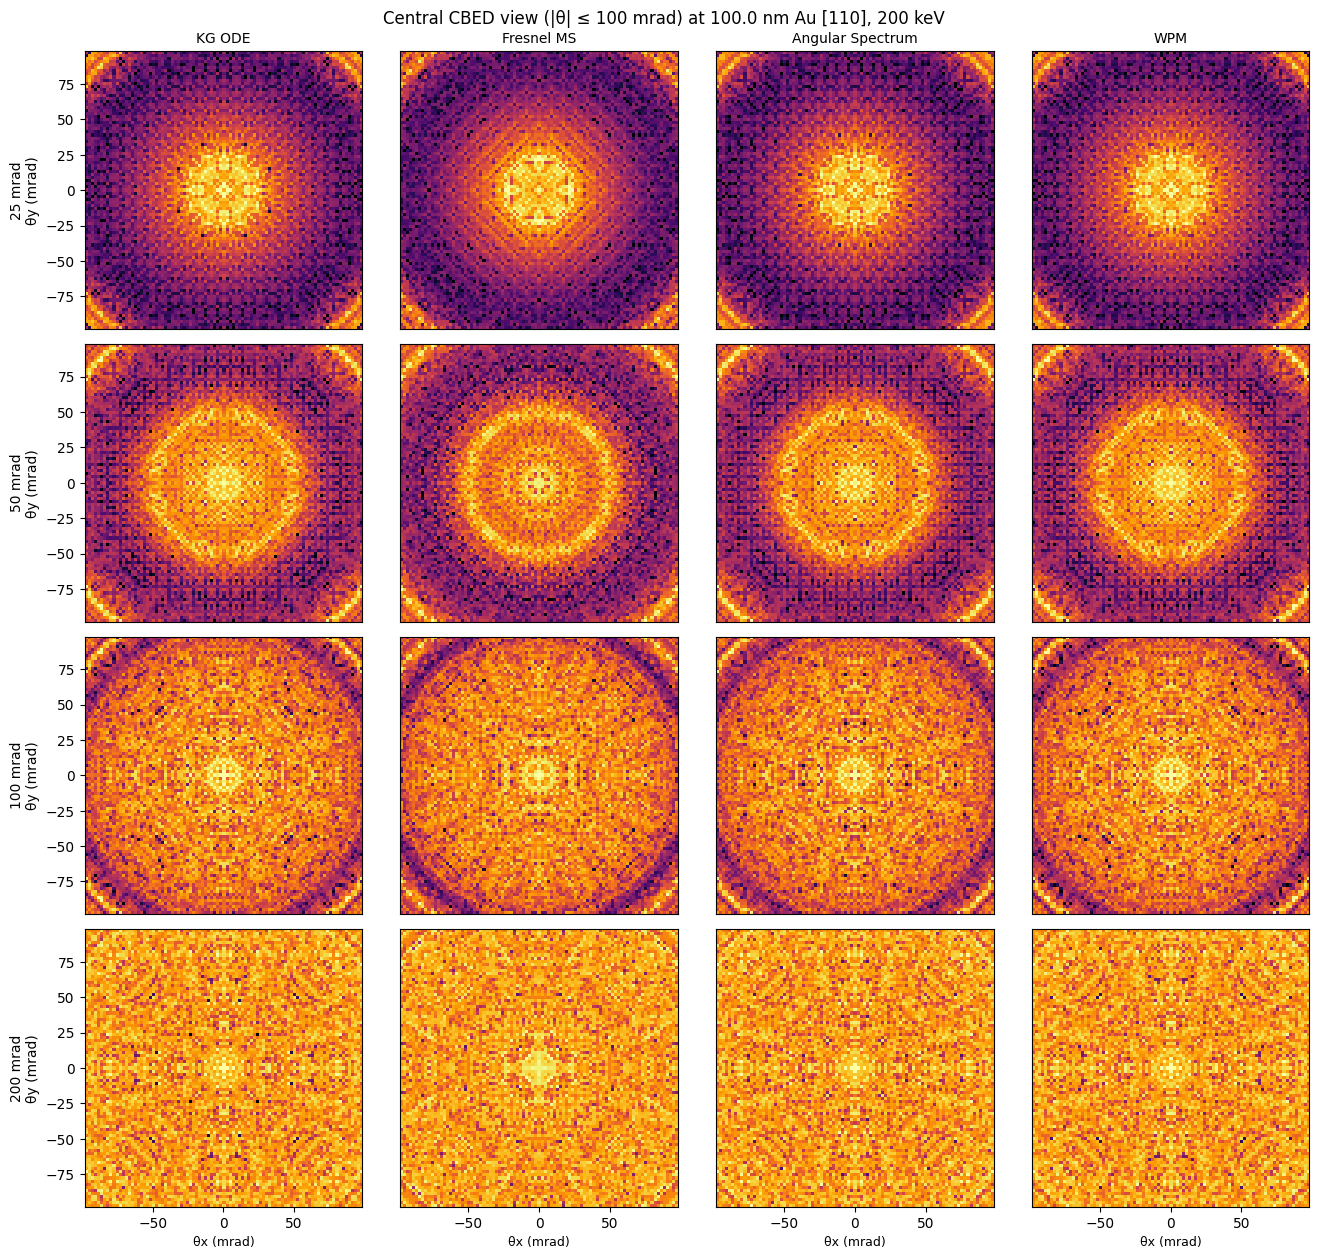

In [61]:
def resolve_paper_fig_dir():
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        candidate = base / "Paper" / "figures"
        if candidate.parent.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    raise FileNotFoundError("Could not locate Paper/figures from the current working directory")

paper_fig_dir = resolve_paper_fig_dir()
plot_methods = method_names
colors = {"Fresnel MS": "C0", "Angular Spectrum": "C1", "WPM": "C2"}
pattern_columns = ["KG ODE", *method_names]

def save_error_figure(error_key, ylabel, title, filename):
    error_ncols = 2
    error_nrows = int(np.ceil(len(PROBE_ANGLES_MRAD) / error_ncols))
    fig_error, error_axes = plt.subplots(
        error_nrows,
        error_ncols,
        figsize=(13, 4.8 * error_nrows),
        sharex=True,
        sharey=True,
    )
    error_axes = np.asarray(error_axes).reshape(-1)
    for ax, alpha in zip(error_axes, PROBE_ANGLES_MRAD):
        angle_results = cbed_results["angles"][float(alpha)]
        for method in plot_methods:
            ax.semilogy(
                cbed_results["thickness_nm"],
                angle_results[error_key][method],
                color=colors[method],
                label=method,
                linewidth=1.8,
            )
        ax.set_title(f"{alpha:.0f} mrad probe")
        ax.set_xlabel("Thickness (nm)")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    for ax in error_axes[len(PROBE_ANGLES_MRAD):]:
        ax.axis("off")
    fig_error.suptitle(title, fontsize=12)
    fig_error.tight_layout()
    output_path = paper_fig_dir / filename
    fig_error.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"Saved -> {output_path}")



def save_error_difference_figure(filename):
    pairs = [
        ("Fresnel MS", "Angular Spectrum"),
        ("Fresnel MS", "WPM"),
        ("Angular Spectrum", "WPM"),
    ]
    pairs = [pair for pair in pairs if pair[0] in method_names and pair[1] in method_names]

    diff_ncols = 2
    diff_nrows = int(np.ceil(len(PROBE_ANGLES_MRAD) / diff_ncols))
    fig_diff, diff_axes = plt.subplots(diff_nrows, diff_ncols, figsize=(13, 4.8 * diff_nrows), sharex=True)
    diff_axes = np.asarray(diff_axes).reshape(-1)

    for ax, alpha in zip(diff_axes, PROBE_ANGLES_MRAD):
        angle_results = cbed_results["angles"][float(alpha)]
        for left, right in pairs:
            diff_curve = angle_results["rel_l2"][left] - angle_results["rel_l2"][right]
            ax.plot(cbed_results["thickness_nm"], diff_curve, linewidth=1.8, label=f"{left} - {right}")
        ax.axhline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
        ax.set_title(f"{alpha:.0f} mrad probe")
        ax.set_xlabel("Thickness (nm)")
        ax.set_ylabel("Error difference (relative L2)")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    for ax in diff_axes[len(PROBE_ANGLES_MRAD):]:
        ax.axis("off")

    fig_diff.suptitle(
        f"Au [110] method error differences vs thickness, {energy/1e3:.0f} keV",
        fontsize=12,
    )
    fig_diff.tight_layout()
    output_path = paper_fig_dir / filename
    fig_diff.savefig(output_path, format="pdf", bbox_inches="tight", dpi=300)
    print(f"Saved -> {output_path}")



def save_pixel_error_map_figure(filename):
    compare_methods = [name for name in method_names if name != "KG ODE"]
    pattern_nrows = len(PROBE_ANGLES_MRAD)
    pattern_ncols = len(compare_methods)
    fig_err, err_axes = plt.subplots(
        pattern_nrows,
        pattern_ncols,
        figsize=(3.6 * pattern_ncols, 3.2 * pattern_nrows),
    )
    err_axes = np.asarray(err_axes).reshape(pattern_nrows, pattern_ncols)

    all_errors_pct = []
    for alpha in PROBE_ANGLES_MRAD:
        angle_results = cbed_results["angles"][float(alpha)]
        y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
            CENTRAL_VIEW_CUTOFF_MRAD,
            ny_g,
            nx_g,
            sampling[0],
            sampling[1],
            wavelength,
        )
        ode_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
        amp_ode = np.sqrt(np.maximum(ode_crop, 0.0))
        for method in compare_methods:
            method_crop = angle_results["final_patterns"][method][y_slice, x_slice]
            amp_method = np.sqrt(np.maximum(method_crop, 0.0))
            err_pct = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
            all_errors_pct.append(err_pct)

    if all_errors_pct:
        flat = np.concatenate([arr.ravel() for arr in all_errors_pct])
        vmax = float(np.percentile(np.abs(flat), 99.5))
    else:
        vmax = 1.0
    if vmax <= 0:
        vmax = 1.0
    norm = None

    im = None
    for row, alpha in enumerate(PROBE_ANGLES_MRAD):
        angle_results = cbed_results["angles"][float(alpha)]
        y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(
            CENTRAL_VIEW_CUTOFF_MRAD,
            ny_g,
            nx_g,
            sampling[0],
            sampling[1],
            wavelength,
        )
        ode_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
        amp_ode = np.sqrt(np.maximum(ode_crop, 0.0))
        extent = [
            theta_x[x_slice.start],
            theta_x[x_slice.stop - 1],
            theta_y[y_slice.start],
            theta_y[y_slice.stop - 1],
        ]

        for col, method in enumerate(compare_methods):
            method_crop = angle_results["final_patterns"][method][y_slice, x_slice]
            amp_method = np.sqrt(np.maximum(method_crop, 0.0))
            err_pct = 100.0 * np.abs(amp_method - amp_ode) / np.maximum(amp_ode, 1e-12)
            im = err_axes[row, col].imshow(
                err_pct,
                cmap="RdBu_r",
                vmin=0.0,
                vmax=vmax,
                origin="lower",
                extent=extent,
            )
            if row == 0:
                err_axes[row, col].set_title(f"{method} vs KG ODE", fontsize=10)
            if col == 0:
                err_axes[row, col].set_ylabel(
                    f"{alpha:.0f} mrad\nθy (mrad)",
                    fontsize=10,
                )
            else:
                err_axes[row, col].set_yticks([])
            if row == pattern_nrows - 1:
                err_axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
            else:
                err_axes[row, col].set_xticks([])

    fig_err.subplots_adjust(right=0.88, wspace=0.06, hspace=0.10)
    cax = fig_err.add_axes([0.90, 0.14, 0.02, 0.72])
    if im is not None:
        cbar = fig_err.colorbar(im, cax=cax)
        cbar.set_label("Absolute amplitude error vs KG ODE (%)")

    fig_err.suptitle(
        f"Pixel-wise CBED absolute amplitude percent error maps at {actual_thickness_nm:.1f} nm "
        f"(|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad)",
        fontsize=12,
    )
    out = paper_fig_dir / filename
    fig_err.savefig(out, format="pdf", bbox_inches="tight", dpi=300)
    print(f"Saved -> {out}")

save_error_figure(
    "rel_l2",
    "Relative L2 error vs KG ODE",
    f"Au [110] CBED error vs thickness, {energy/1e3:.0f} keV",
    "cbed_error_vs_thickness.pdf",
)
save_error_difference_figure("cbed_error_differences_vs_thickness.pdf")
save_pixel_error_map_figure("cbed_pixel_error_maps_vs_ode.pdf")
has_central_ring_curves = all(
    np.isfinite(cbed_results["angles"][float(alpha)]["central_ring_rel_l2"][method]).any()
    for alpha in PROBE_ANGLES_MRAD
    for method in method_names
)
if has_central_ring_curves:
    save_error_figure(
        "central_ring_rel_l2",
        "Central-ring relative L2 error vs KG ODE",
        f"Au [110] central-ring CBED error vs thickness, {energy/1e3:.0f} keV",
        "cbed_central_ring_error_vs_thickness.pdf",
    )
else:
    print("Skipped central-ring error export: loaded results do not contain central-ring curves.")

pattern_nrows = len(PROBE_ANGLES_MRAD)
pattern_ncols = len(pattern_columns)
fig_patterns, pattern_axes = plt.subplots(
    pattern_nrows,
    pattern_ncols,
    figsize=(3.4 * pattern_ncols, 3.2 * pattern_nrows),
)
pattern_axes = np.asarray(pattern_axes).reshape(pattern_nrows, pattern_ncols)
for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(CENTRAL_VIEW_CUTOFF_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength)
    reference = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    positive = reference[reference > 0]
    vmax = float(np.percentile(reference, 99.8))
    vmin = float(max(vmax * 1e-5, positive.min())) if positive.size else max(vmax * 1e-5, 1e-30)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    for col, name in enumerate(pattern_columns):
        pattern_axes[row, col].imshow(
            angle_results["final_patterns"][name][y_slice, x_slice],
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap="inferno",
            origin="lower",
            extent=extent,
        )
        if row == 0:
            pattern_axes[row, col].set_title(name, fontsize=10)
        if col == 0:
            pattern_axes[row, col].set_ylabel(f"{alpha:.0f} mrad\nθy (mrad)", fontsize=10)
        else:
            pattern_axes[row, col].set_yticks([])
        if row == pattern_nrows - 1:
            pattern_axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
        else:
            pattern_axes[row, col].set_xticks([])
fig_patterns.suptitle(
    f"Final central CBED view (|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad) at {actual_thickness_nm:.1f} nm Au [110], {energy/1e3:.0f} keV",
    fontsize=12,
)
fig_patterns.tight_layout()
patterns_path = paper_fig_dir / "cbed_final_pattern_grid.pdf"
fig_patterns.savefig(patterns_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved -> {patterns_path}")

fig_zoom, zoom_axes = plt.subplots(pattern_nrows, pattern_ncols, figsize=(3.4 * pattern_ncols, 3.2 * pattern_nrows))
zoom_axes = np.asarray(zoom_axes).reshape(pattern_nrows, pattern_ncols)
for row, alpha in enumerate(PROBE_ANGLES_MRAD):
    angle_results = cbed_results["angles"][float(alpha)]
    y_slice, x_slice, theta_y, theta_x = central_crop_slices_by_cutoff(CENTRAL_VIEW_CUTOFF_MRAD, ny_g, nx_g, sampling[0], sampling[1], wavelength)
    reference_crop = angle_results["final_patterns"]["KG ODE"][y_slice, x_slice]
    positive = reference_crop[reference_crop > 0]
    vmax = float(np.percentile(reference_crop, 99.8))
    vmin = float(max(vmax * 1e-5, positive.min())) if positive.size else max(vmax * 1e-5, 1e-30)
    extent = [theta_x[x_slice.start], theta_x[x_slice.stop - 1], theta_y[y_slice.start], theta_y[y_slice.stop - 1]]
    for col, name in enumerate(pattern_columns):
        zoom_axes[row, col].imshow(
            angle_results["final_patterns"][name][y_slice, x_slice],
            norm=LogNorm(vmin=vmin, vmax=vmax),
            cmap="inferno",
            origin="lower",
            extent=extent,
        )
        if row == 0:
            zoom_axes[row, col].set_title(name, fontsize=10)
        if col == 0:
            zoom_axes[row, col].set_ylabel(f"{alpha:.0f} mrad\nθy (mrad)", fontsize=10)
        else:
            zoom_axes[row, col].set_yticks([])
        if row == pattern_nrows - 1:
            zoom_axes[row, col].set_xlabel("θx (mrad)", fontsize=9)
        else:
            zoom_axes[row, col].set_xticks([])
fig_zoom.suptitle(
    f"Central CBED view (|θ| ≤ {CENTRAL_VIEW_CUTOFF_MRAD:.0f} mrad) at {actual_thickness_nm:.1f} nm Au [110], {energy/1e3:.0f} keV",
    fontsize=12,
)
fig_zoom.tight_layout()
zoom_path = paper_fig_dir / "cbed_final_central_zoom_grid.pdf"
fig_zoom.savefig(zoom_path, format="pdf", bbox_inches="tight", dpi=300)
print(f"Saved -> {zoom_path}")


## Summary table

In [62]:
print(f"Au [110], {energy/1e3:.0f} keV, final thickness = {actual_thickness_nm:.1f} nm")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) Å")
print(f"ODE/test z-sampling: {ODE_SLICES_PER_CELL}/{TEST_SLICES_PER_CELL} slices per cell")

header = f"{'Angle (mrad)':>12s} {'Method':>18s} {'Final Rel L2':>14s} {'Final Ring L2':>14s} {'Mean runtime/cell (s)':>22s}"
print(header)
print("-" * len(header))
for alpha in PROBE_ANGLES_MRAD:
    angle_results = cbed_results["angles"][float(alpha)]
    for method in method_names:
        final_error = angle_results["rel_l2"][method][-1]
        ring_error = angle_results["central_ring_rel_l2"][method][-1]
        ring_text = f"{ring_error:>14.4e}" if np.isfinite(ring_error) else f"{'n/a':>14s}"
        mean_time = float(np.mean(angle_results["runtime_s"][method]))
        print(f"{alpha:>12.0f} {method:>18s} {final_error:>14.4e} {ring_text} {mean_time:>22.3f}")


Au [110], 200 keV, final thickness = 100.0 nm
Grid: (256, 256), sampling = (0.0450, 0.0450) Å
ODE/test z-sampling: 64/32 slices per cell
Angle (mrad)             Method   Final Rel L2  Final Ring L2  Mean runtime/cell (s)
------------------------------------------------------------------------------------
          25         Fresnel MS     9.9244e-01            n/a                  0.056
          25   Angular Spectrum     1.9321e-01            n/a                  0.054
          25                WPM     4.3634e-02            n/a                  0.461
          50         Fresnel MS     1.1930e+00            n/a                  0.054
          50   Angular Spectrum     2.2910e-01            n/a                  0.053
          50                WPM     5.3701e-02            n/a                  0.444
         100         Fresnel MS     1.1109e+00            n/a                  0.054
         100   Angular Spectrum     2.2663e-01            n/a                  0.056
         100 